## Prep

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

# GOOGLE_DRIVE_PATH = os.path.join('drive', 'My Drive', GOOGLE_DRIVE_PATH_AFTER_MYDRIVE)

# files = os.listdir(GOOGLE_DRIVE_PATH)
files = os.listdir(".")
expected_files = [ 'ROB498_hw3.ipynb', 'learning_state_dynamics.py', 'panda_pushing_env.py', 'visualizers.py',  'mppi.py', 'validation_data.npy']

# sys.path.append(GOOGLE_DRIVE_PATH)

# Verify that there are all the expected files in the directory
all_found = True
for expected_file in expected_files:
  if expected_file not in files:
    print(f'Required file {expected_file} not found!')
    all_found = False
if all_found:
  print('All required files are found :)')

All required files are found :)


In [3]:
import torch
import os
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from numpngw import write_apng
from IPython.display import Image
from tqdm.notebook import tqdm
import time

### Simulation Environment (from HW3)

For our planar pushing setup, we will use PyBullet to simulate a panda robot that pushes a block on top of a table.
The pushing block is visualized in white. In green, we visualize the goal pose of the block.



In [4]:
from panda_pushing_env import PandaPushingEnv
from visualizers import GIFVisualizer, NotebookVisualizer
from IPython.display import display

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
pybullet build time: Oct 21 2025 11:20:22


Run the following code block to visualize the robot pushing the block.

In [5]:
# %matplotlib inline

# # Create the visualizer
# fig = plt.figure(figsize=(8,8))
# hfig = display(fig, display_id=True)
# visualizer = NotebookVisualizer(fig=fig, hfig=hfig)

# # Initialize the simulation environment
# env = PandaPushingEnv(visualizer=visualizer, render_non_push_motions=True,  camera_heigh=800, camera_width=800)
# env.reset()

# # Perform a sequence of 3 random actions:
# for i in tqdm(range(3)):
#     action_i = env.action_space.sample()
#     state, reward, done, info = env.step(action_i)
#     if done:
#         break

# plt.close(fig)

For speeding up the visualization, we will only visualize the pushing part of the robot motion. However, be aware of the full robot motion.

There is another option for visualization, which is to create a `.gif` file. The following cell shows an example of this. Note that here we set the rendering mode to just render the push motion for efficiency.

  0%|          | 0/10 [00:00<?, ?it/s]

Creating animated gif, please wait about 10 seconds


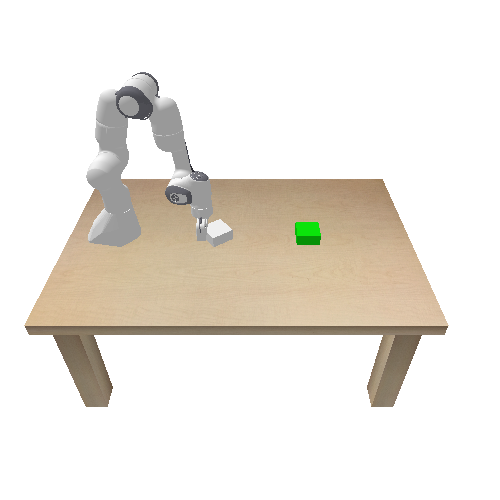

In [6]:
# Create the GIF visualizer
visualizer = GIFVisualizer()

# Initialize the simulation environment. This will only render push motions, omitting the robot reseting motions.
env = PandaPushingEnv(visualizer=visualizer, render_non_push_motions=False, camera_heigh=500, camera_width=500, render_every_n_steps=5)
env.reset()

# Perform a sequence of 3 random actions:
for i in tqdm(range(10)):
    action_i = env.action_space.sample()
    state, reward, done, info = env.step(action_i)
    if done:
        break

# Create and visualize the gif file.
Image(filename=visualizer.get_gif())



Rendering is useful for visualizing the implementation's performance and debugging. However, it consumes resources and takes time to produce. The following cell will perform 100 pushes without rendering. Compare the time with the previous rendering approaches. This should be an order of magnitude faster.

In [7]:
# # Simulate pushing without rendering - this should take about 30s.
# visualizer = None # No redering

# env = PandaPushingEnv(visualizer=visualizer)
# env.reset()

# pbar =  tqdm(range(100)) # We will perform 100 pushes.

# for i in pbar:
#     action_i = env.action_space.sample()
#     state, reward, done, info = env.step(action_i)
#     if done:
#         env.reset()


### State Space and Action Space

For the planar pushing task, we have the following action and state spaces:

The image below illustrates the state space, which is the block planar location on top of the table. 
$$
\mathbf x = \begin{bmatrix} x & y & \theta\end{bmatrix}^\top\in \text{SE}(2)
$$
Note that the state contains only position elements, and not velocity terms. This is because we assume that the pushing task is *quasi-static*. This means that the pushing actions are slow enough that the velocity and inertia of the block are negligible. In other words, if the robot stops pushing, the block also stops.


![State Space](state_space.png)


Note that the robot is centered at the origin. 


The following image show the robot action space. 

![Action Space](action_space.png)


Each action $\mathbf u = \begin{bmatrix} p & \phi & \ell\end{bmatrix}^\top\in \mathbb R^3$ is composed by:
* $p \in [-1,1]$: pushing location along the lower block edge.
* $\phi \in [-\frac{\pi}{2},\frac{\pi}{2}]$ pushing angle.
* $\ell\in [0,1]$ pushing length as a fraction of the maximum pushing length. The maximum pushing length is is 0.1 m



### Gym Environments

Our planar pushing task has been wrapped into a `gym` environment. You can find more information about the gym environments [here](https://gymnasium.farama.org/api/env/).

As a gym enviroment, our pushing enviroment has the following useful methods:

* `step`: Given an action vector, it performs the action in the simulator and returns 
    1. `state`: The resulting state, i.e. $s_{t+1}$
    2. `reward`: Not used here (useful for Reinforcement Learning tasks).
    3. `done`: Boolean. In our case the simulation is done (`done=True`) if the robot has reached the goal location or if the block has left the bounds of the workspace.
    4. `info`: Dictionary containing additional data. Not used here.
Example:
```python
state, reward, done, info = env.step(action_i)
```
* `reset`: Resets the simulation to the initial state. It returns the inital state after reset.
Example:
```python
    state = env.reset()
```

Moreover, our pushing environment has the following attributes:
* `env.action_space`: Represents the action space, following the described parametrization above.
* `env.observation_space`: Represents the state space (block pose in $SE(2)$)
These are `gym.spaces` and therefore you can sample them using `.sample()`.
Example:
```python
action_i = env.action_space.sample()
```
This produces actions uniformly sampled from the action space.

You can find more info about gym spaces [here](https://gymnasium.farama.org/api/spaces/).



## 1 - Collect Data  (From HW3)

Given the environment, the first step is to collect data. The collected data will then be used to train a model of the pushing dynamics.

**TODO:**

* Implement `collect_data_random` in `learning_state_dynamics.py` which collects data trajectories. The actions should be uniformly random sampled within the action space limits.


**OBSERVATION**: Data collection may take some time. Please be patient and do not close the session while you are collecting data or the data collection process may be interrupted. Once the data is collected it will be saved, so if you restart the kernel you will not need to recollect the data.


**GRADING**: For grading you will also have to submit the saved collected data file `collected_data.npy`. We will check that the collected data is in the required format. However, we will NOT check the quality of the data. Note that for training a good model, data quality is key. Your collected data should be diverse to train an effective model of pushing dynamics.


In [8]:
# # Collect data (it may take some time)
# from learning_state_dynamics import collect_data_random

# # Data collection parameters
# N = 100 # Number of trajectories
# T = 10 # Trajectory length

# # Initialize the environment and collect data
# env = PandaPushingEnv()
# env.reset()
# collected_data = collect_data_random(env, num_trajectories=N, trajectory_length=T)


# # Verify the number of data collected:
# print(f'We have collected {len(collected_data)} trajectories')
# print('A data sample contains: ')
# for k, v in collected_data[0].items():
#     assert(type(v) == np.ndarray)
#     assert(v.dtype == np.float32)
#     print(f'\t {k}: numpy array of shape {v.shape}')

# # Save the collected data into a file
# #np.save(os.path.join(GOOGLE_DRIVE_PATH, 'collected_data.npy'), collected_data)
# np.save('collected_data.npy', collected_data)


In [9]:
# Load the collected data: 
# collected_data = np.load(os.path.join(GOOGLE_DRIVE_PATH, 'collected_data.npy'), allow_pickle=True)
collected_data = np.load('collected_data.npy', allow_pickle=True)

## 2 - Data Processing (From HW3)
Next, given the collected data you will have to process it so we can use it for training the model.


### 2.1 - Single Step Data

Here we will process the data in a single-step format. 


**TODO:**

* Implement `process_data_single_step` in `learning_state_dyanmics.py` to pack the collected data into a Dataset and returns a DataLoader for training and for validation.
You should do this via the following steps:
 1. Implement `SingleStepDynamicsDataset` which wraps the collected data into a PyTorch Dataset.
    * For this part you only need to implement the `__getitem__` method which returns the data $(\mathbf x_t, \mathbf u_t, \mathbf x_{t+1})$ as a dictionary
    * Your dataset should consist of all $(\mathbf x_t, \mathbf u_t, \mathbf x_{t+1})$ in the collected data
 2. You should instantiate your `SingleStepDynamicsDataset` using the entire dataset, and use `torch.utils.data.random_split` to split the dataset into train and validation sets.  https://pytorch.org/docs/stable/data.html#torch.utils.data.random_split. You should do a 80%-20% split.
 3. You should return a DataLoader for the training and validation set which loads batches of the data of the required `batch_size`.

In [10]:
# Process the data
from learning_state_dynamics import process_data_single_step, SingleStepDynamicsDataset

batch_size = 500
train_loader, val_loader = process_data_single_step(collected_data, batch_size=batch_size)

# let's check your dataloader

# you should return a dataloader
print('Is the returned train_loader a DataLoader?')
print('Yes' if isinstance(train_loader, torch.utils.data.DataLoader) else 'No')
print('')

# You should have used random split to split your data - 
# this means the validation and training sets are both subsets of an original dataset
print('Was random_split used to split the data?')
print('Yes' if isinstance(train_loader.dataset, torch.utils.data.Subset) else 'No')
print('')

# The original dataset should be of a SingleStepDynamicsDataset
print('Is the dataset a SingleStepDynamicsDataset?')
print('Yes' if isinstance(train_loader.dataset.dataset, SingleStepDynamicsDataset) else 'No')
print('')

# we should see the state, action and next state of shape (batch_size, 3)
for item in train_loader:
    print(f'state is shape {item["state"].shape}')
    print(f'action is shape {item["action"].shape}')
    print(f'next_state is shape {item["next_state"].shape}')
    break


Is the returned train_loader a DataLoader?
Yes

Was random_split used to split the data?
Yes

Is the dataset a SingleStepDynamicsDataset?
Yes

state is shape torch.Size([500, 3])
action is shape torch.Size([500, 3])
next_state is shape torch.Size([500, 3])


### 2.2 - Multi-step Data

Here we will process the data in a multi-step format. 


**TODO:**

* Implement `process_data_multiple_step` in `learning_state_dyanmics.py` to pack the collected data into a Dataset and return a DataLoader for training and for validation.
You should do this via the following steps:
 1. Implement `MultiStepDynamicsDataset` which wraps the collected data into a PyTorch Dataset.
    * For this part you only need to implement the `__getitem__` method which returns $(\mathbf x_t, \mathbf u_t, ..., \mathbf u_{t+k-1}, \mathbf x_{t+1}, ... , \mathbf x_{t+k})$, where $k$ is `num_steps`. We will be using `num_steps=4`. 
    * Your dataset should consist of all subtrajectories of the above form in the dataset. For instance, the trajectory $[(\mathbf x_1,\mathbf  u_1), (\mathbf x_2, \mathbf u_2), (\mathbf x_3, \mathbf u_3), (\mathbf x_4, \mathbf u_4), (\mathbf x_5, \mathbf u_5), (\mathbf x_6, \mathbf u_6), (\mathbf x_7)]$ should result in the following items in the dataset:
        - $(\mathbf x_1, \mathbf u_1, \mathbf u_2, \mathbf u_3, \mathbf u_4, \mathbf x_2, \mathbf x_3, \mathbf x_4, \mathbf x_5)$
        - $(\mathbf x_2, \mathbf u_2, \mathbf u_3, \mathbf u_4, \mathbf u_5, \mathbf x_3, \mathbf x_4, \mathbf x_5, \mathbf x_6)$
        - $(\mathbf x_3, \mathbf u_3, \mathbf u_4, \mathbf u_5, \mathbf u_6, \mathbf x_4, \mathbf x_5, \mathbf x_6, \mathbf x_7)$
 2. You should instantiate your `MultiStepDynamicsDataset` using the entire dataset, and use `torch.utils.data.random_split` to split the dataset into train and validation sets  https://pytorch.org/docs/stable/data.html#torch.utils.data.random_split. You should do a 80%-20% split.
 3. You should return a DataLoader for the training and validation set which loads batched of the data of the required `batch_size`.

In [11]:
# Process the data
from learning_state_dynamics import process_data_multiple_step, MultiStepDynamicsDataset


train_loader, val_loader = process_data_multiple_step(collected_data, batch_size=500)

# let's check your dataloader

# you should return a dataloader
print('Is the returned train_loader a DataLoader?')
print('Yes' if isinstance(train_loader, torch.utils.data.DataLoader) else 'No')
print('')

# You should have used random split to split your data - 
# this means the validation and training sets are both subsets of an original dataset
print('Was random_split used to split the data?')
print('Yes' if isinstance(train_loader.dataset, torch.utils.data.Subset) else 'No')
print('')

# The original dataset should be of a MultiStepDynamicsDataset
print('Is the dataset a SingleStepDynamicsDataset?')
print('Yes' if isinstance(train_loader.dataset.dataset, MultiStepDynamicsDataset) else 'No')
print('')

# we should see the state is shape (batch_size, 3)
# and action, next_state are shape (batch_size, num_steps, 3)
for item in train_loader:
    print(f'state is shape {item["state"].shape}')
    print(f'action is shape {item["action"].shape}')
    print(f'next_state is shape {item["next_state"].shape}')
    break

Is the returned train_loader a DataLoader?
Yes

Was random_split used to split the data?
Yes

Is the dataset a SingleStepDynamicsDataset?
Yes

state is shape torch.Size([500, 3])
action is shape torch.Size([500, 4, 3])
next_state is shape torch.Size([500, 4, 3])


## 3 - NeuralODE Method

Install torchdiffeq

In [12]:
# !pip install torchdiffeq

In [13]:
from torchdiffeq import odeint_adjoint as odeint

In [14]:
import torch.optim as optim
from learning_state_dynamics import (
    NeuralODEModel,
    SE2PoseLoss,
    SingleStepLoss,
    process_data_single_step
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Cuda is available:", torch.cuda.is_available())

Cuda is available: True


### 3.1 - Single step

In [15]:
# 3) Instantiate the NeuralODE
#   - state_dim=3, action_dim=3 for the planar‐pushing SE(2) state+action
#   - hidden_sizes matches your HW3 nets ([100,100])
#   - method can be 'rk4', 'dopri5', or 'euler'
model = NeuralODEModel(
    state_dim=3,
    action_dim=3,
    hidden_sizes=[100,100],
    method='dopri5'
).to(device)

In [16]:
# 5) Loss
pose_loss = SE2PoseLoss(block_width=0.1, block_length=0.1)
step_loss = SingleStepLoss(pose_loss)

In [17]:
# 6) (Re-)define train/val loops to push to device

def train_step(model, loader, optimizer):
    model.train()
    total = 0.0
    for batch in loader:
        s = batch['state'].to(device)
        u = batch['action'].to(device)
        s_next = batch['next_state'].to(device)

        optimizer.zero_grad()
        loss = step_loss(model, s, u, s_next)
        loss.backward()
        optimizer.step()

        total += loss.item()
    return total/len(loader)

def val_step(model, loader):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for batch in loader:
            s = batch['state'].to(device)
            u = batch['action'].to(device)
            s_next = batch['next_state'].to(device)

            loss = step_loss(model, s, u, s_next)
            total += loss.item()
    return total/len(loader)

# 7) Training loop
def train_model(model, train_loader, val_loader, num_epochs=1000, lr=1e-3):

    # check device
    try:
        dev = next(model.parameters()).device
    except StopIteration:
        dev = torch.device("cpu")
    print(f"Training on device: {dev}")


    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses, val_losses = [], []

    start_time = time.time()
    # Epoch bar shows elapsed and remaining time
    epoch_bar = tqdm(range(1, num_epochs+1), desc="Epochs", unit="epoch")
    for epoch in epoch_bar:
        tr = train_step(model, train_loader, optimizer)
        vl = val_step(model, val_loader)
        train_losses.append(tr)
        val_losses.append(vl)
        # update losses in the bar
        epoch_bar.set_postfix(train_loss=f"{tr:.4e}", val_loss=f"{vl:.4e}")

    total_secs = time.time() - start_time
    mins, secs = divmod(total_secs, 60)
    print(f"\nTraining completed in {int(mins)}m {secs:.1f}s total")

    return train_losses, val_losses




In [18]:
# 8) Run it
LR = 1e-2
EPOCHS = 100
train_loader, val_loader = process_data_single_step(collected_data, batch_size=batch_size)
train_losses, val_losses = train_model(model, train_loader, val_loader, num_epochs=EPOCHS, lr=LR)

Training on device: cuda:0


Epochs:   0%|          | 0/100 [00:00<?, ?epoch/s]


Training completed in 0m 50.3s total


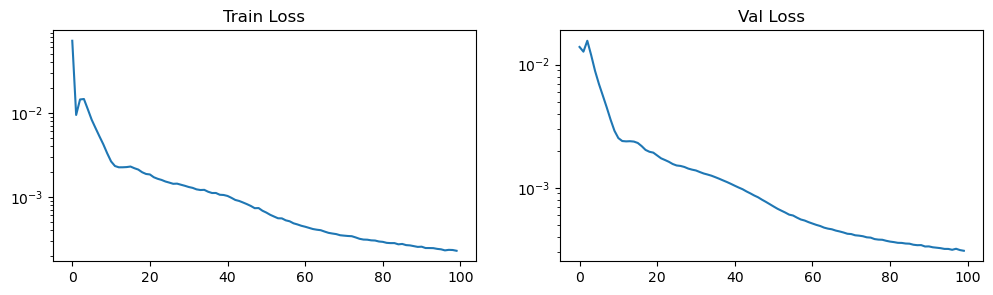

In [15]:
# 9) Plot
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1,2,figsize=(12,3))
axs[0].plot(train_losses); axs[0].set(title="Train Loss", yscale='log')
axs[1].plot(val_losses  ); axs[1].set(title="Val Loss",   yscale='log')
plt.show()

In [16]:
# # 10) Save
# torch.save(model.state_dict(), 'pushing_singlestep_neuralode_model.pt')

### 3.2 - Multiple steps

In [17]:
from learning_state_dynamics import MultiStepLoss

In [18]:
# 2) Build multi-step dataloaders
num_steps  = 4
batch_size = 500
train_loader, val_loader = process_data_multiple_step(
    collected_data,
    batch_size=batch_size,
    num_steps=num_steps
)

# 3) Instantiate Neural-ODE as multi_model
state_dim, action_dim = 3, 3
hidden_sizes = [100, 100]
multi_model = NeuralODEModel(
    state_dim=state_dim,
    action_dim=action_dim,
    hidden_sizes=hidden_sizes,
    # NOTE: dopri5 cause slow training
    method='rk4'            # can be 'euler' / 'dopri5rk4' / 'rk4'
).to(device)

# 4) Multi-step loss
pose_loss_fn = SE2PoseLoss(block_width=0.1, block_length=0.1)
step_loss    = MultiStepLoss(pose_loss_fn, discount=0.9)

# (train_step / val_step will now call step_loss(multi_model, state, action, next_state))

Note: Ran steps 5 and 6 multiple times with different hyperparameters, but improving the same model.

In [19]:
# 5) Hyperparameters
LR         = 1e-4
NUM_EPOCHS = 100

Training on device: cuda:0


Epochs:   0%|          | 0/100 [00:00<?, ?epoch/s]


Training completed in 0m 15.1s total


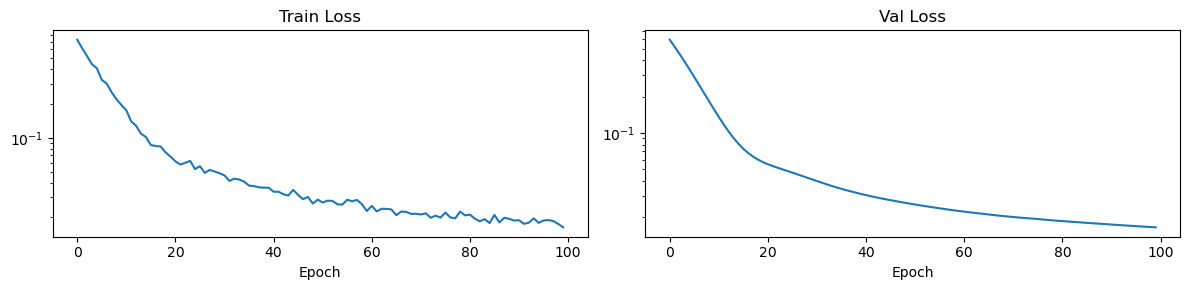

In [20]:
# 6) Train
train_losses, val_losses = train_model(
    multi_model,
    train_loader,
    val_loader,
    num_epochs=NUM_EPOCHS,
    lr=LR
)
# 7) Plot losses
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(train_losses)
axes[0].set(title="Train Loss",   yscale='log', xlabel="Epoch")
axes[1].plot(val_losses)
axes[1].set(title="Val Loss",     yscale='log', xlabel="Epoch")
plt.tight_layout()
plt.show()

In [21]:
# # 8) Save model
# torch.save(multi_model.state_dict(), 'pushing_multistep_neuralode_model.pt')

###  3.3 - Single_step: A grid search of hyperparameters

#### 3.3.1 - Broad search of possible parameters

In [162]:
import itertools
import time
import torch
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm

from learning_state_dynamics import (
    NeuralODEModel,
    SE2PoseLoss,
    SingleStepLoss,
    process_data_single_step
)


In [211]:
# 1) Hyperparameter grid
lrs     = [1e-2, 1e-3, 1e-4]
methods = ['euler', 'rk4', 'dopri5']
NUM_EPOCHS = 150
BATCH_SIZE  = 500


In [212]:
# 2) Prepare data
collected_data = np.load('collected_data.npy', allow_pickle=True)
train_loader, val_loader = process_data_single_step(collected_data, BATCH_SIZE)

In [213]:
# 3) Device & losses
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pose_loss = SE2PoseLoss(block_width=0.1, block_length=0.1)
step_loss = SingleStepLoss(pose_loss)

# 4) Training helper
import torch.optim as optim
def train_and_validate(model, lr):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    # train
    model.to(device).train()
    for _ in range(NUM_EPOCHS):
        for batch in train_loader:
            s, u, s_next = (batch['state'].to(device),
                            batch['action'].to(device),
                            batch['next_state'].to(device))
            optimizer.zero_grad()
            loss = step_loss(model, s, u, s_next)
            loss.backward()
            optimizer.step()
    # validate
    model.eval()
    with torch.no_grad():
        total = 0.0
        for batch in val_loader:
            s, u, s_next = (batch['state'].to(device),
                            batch['action'].to(device),
                            batch['next_state'].to(device))
            total += step_loss(model, s, u, s_next).item()
    return total / len(val_loader)

# 5) Grid search loop
results = []
for lr, method in tqdm(itertools.product(lrs, methods), 
                       total=len(lrs)*len(methods), desc="Grid Search"):
    net = NeuralODEModel(state_dim=3, action_dim=3,
                         hidden_sizes=[100,100],
                         method=method)
    val_loss = train_and_validate(net, lr)
    results.append({'method': method, 'lr': lr, 'val_loss': val_loss})

Grid Search:   0%|          | 0/9 [00:00<?, ?it/s]

In [216]:
# 6) Show results
df = pd.DataFrame(results)
print(df.pivot(index='lr', columns='method', values='val_loss'))

method    dopri5     euler       rk4
lr                                  
0.0001  0.001332  0.001058  0.001075
0.0010  0.000116  0.000235  0.000166
0.0100  0.000224  0.000133  0.000351


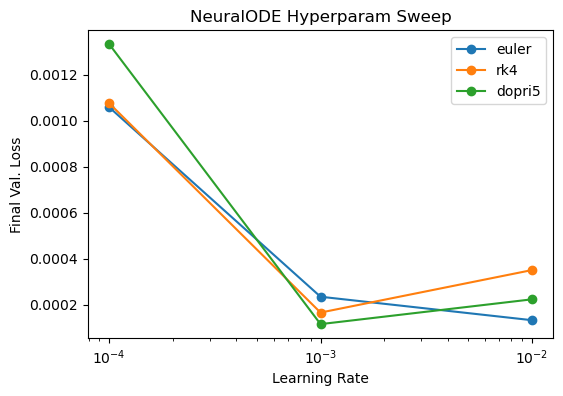

In [217]:
# 7) Plot
plt.figure(figsize=(6,4))
for m in methods:
    plt.plot(lrs, df[df.method==m].val_loss, '-o', label=m)
plt.xscale('log')
plt.xlabel('Learning Rate')
plt.ylabel('Final Val. Loss')
plt.title('NeuralODE Hyperparam Sweep')
plt.legend()
plt.show()


Conclusions so far:  
dopri5 > rk4 > euler  
good learning rate around 10e-3

#### 3.3.2 - Narrowing search down, testing only rk4 for time concerns

Running more sophisticated grid search,  
Eliminating euler and focusing around lr = 10e-3.

Added note: dopri5 is taking too long; grid search with rk4 only first, then test the best param on dopri5.

In [27]:
# 1) Grid settings
# methods    = ['rk4', 'dopri5']
methods    = ['rk4']
lrs        = [7e-4, 1e-3, 3e-3, 5e-3, 7e-3]
NUM_EPOCHS = 700
EVAL_INTERVAL = 20  # record val loss every 10 epochs

In [28]:
# 2) Train+validate that records intermediate losses
def train_validate(method, lr):
    model = NeuralODEModel(3,3,[100,100],method).to(device)
    optim = torch.optim.Adam(model.parameters(), lr=lr)
    val_losses = []
    
    for epoch in range(1, NUM_EPOCHS+1):
        # --- training step
        model.train()
        for b in train_loader:
            s,u,sn = b['state'].to(device), b['action'].to(device), b['next_state'].to(device)
            optim.zero_grad()
            loss = step_loss(model, s, u, sn)
            loss.backward(); optim.step()
        
        # --- validation at interval
        if epoch % EVAL_INTERVAL == 0:
            model.eval()
            tot = 0.0
            with torch.no_grad():
                for b in val_loader:
                    s,u,sn = b['state'].to(device), b['action'].to(device), b['next_state'].to(device)
                    tot += step_loss(model, s, u, sn).item()
            val_losses.append(tot / len(val_loader))
    
    return val_losses

In [29]:
# 3) Run sweep with tqdm
results = {}
for method in tqdm(methods, desc="Integrator"):
    for lr in tqdm(lrs, desc=f"LRs for {method}", leave=False):
        vals = train_validate(method, lr)
        results[(method,lr)] = vals


Integrator:   0%|          | 0/1 [00:00<?, ?it/s]

LRs for rk4:   0%|          | 0/5 [00:00<?, ?it/s]

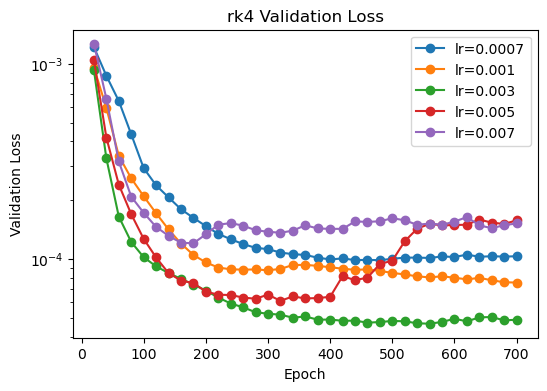

In [30]:
# 4) Plotting with log-scale on the y-axis
epochs = list(range(EVAL_INTERVAL, NUM_EPOCHS+1, EVAL_INTERVAL))

for method in methods:
    plt.figure(figsize=(6,4))
    for lr in lrs:
        plt.plot(
            epochs,
            results[(method, lr)],
            marker='o',
            label=f'lr={lr}'
        )
    plt.title(f"{method} Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.yscale('log')         # <-- log scale on y-axis
    plt.legend()
    plt.show()

In [31]:
for (method, lr), losses in results.items():
    final = losses[-1]
    print(f"{method:10s}  lr={lr:<7g}  → final val loss = {final:.4e}")


rk4         lr=0.0007   → final val loss = 1.0331e-04
rk4         lr=0.001    → final val loss = 7.5778e-05
rk4         lr=0.003    → final val loss = 4.8906e-05
rk4         lr=0.005    → final val loss = 1.5788e-04
rk4         lr=0.007    → final val loss = 1.5222e-04


Conclusion for the above:  
lr = 0.005 is best, although not always  
(Sometimes,) Min around 380; stop training / lower lr at around 350 epochs

More sophisticated grid search.

In [148]:
# 1) Grid settings
# methods    = ['rk4', 'dopri5']
methods    = ['rk4']
lrs        = [1e-3, 3e-3, 5e-3, 7e-3]
NUM_EPOCHS = 1000
EVAL_INTERVAL = 20  # record val loss every 10 epochs

# Make a directory to save models
save_dir = "single_rk4_models"
os.makedirs(save_dir, exist_ok=True)

In [149]:
# 2) Train+validate that records intermediate losses
def train_validate(method, lr):
    model = NeuralODEModel(3,3,[100,100],method).to(device)
    optim = torch.optim.Adam(model.parameters(), lr=lr)
    val_losses = []
    
    for epoch in range(1, NUM_EPOCHS+1):
        # --- training step
        model.train()
        for b in train_loader:
            s,u,sn = b['state'].to(device), b['action'].to(device), b['next_state'].to(device)
            optim.zero_grad()
            loss = step_loss(model, s, u, sn)
            loss.backward(); optim.step()
        
        # --- validation at interval
        if epoch % EVAL_INTERVAL == 0:
            model.eval()
            tot = 0.0
            with torch.no_grad():
                for b in val_loader:
                    s,u,sn = b['state'].to(device), b['action'].to(device), b['next_state'].to(device)
                    tot += step_loss(model, s, u, sn).item()
            val_losses.append(tot / len(val_loader))

    # --- Save model after training
    model_path = os.path.join(save_dir, f"model_{method}_lr{lr}.pt")
    torch.save(model.state_dict(), model_path)
    
    return val_losses

In [150]:
# 3) Run sweep with tqdm
results = {}
for method in tqdm(methods, desc="Integrator"):
    for lr in tqdm(lrs, desc=f"LRs for {method}", leave=False):
        vals = train_validate(method, lr)
        results[(method,lr)] = vals


Integrator:   0%|          | 0/1 [00:00<?, ?it/s]

LRs for rk4:   0%|          | 0/4 [00:00<?, ?it/s]

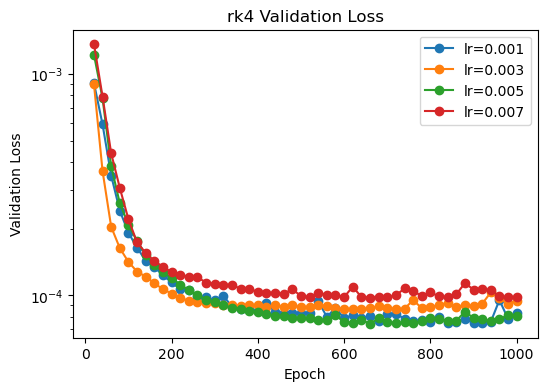

In [151]:
# 4) Plotting with log-scale on the y-axis
epochs = list(range(EVAL_INTERVAL, NUM_EPOCHS+1, EVAL_INTERVAL))

for method in methods:
    plt.figure(figsize=(6,4))
    for lr in lrs:
        plt.plot(
            epochs,
            results[(method, lr)],
            marker='o',
            label=f'lr={lr}'
        )
    plt.title(f"{method} Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.yscale('log')         # <-- log scale on y-axis
    plt.legend()
    plt.show()

In [153]:
for (method, lr), losses in results.items():
    final = losses[-1]
    print(f"{method:10s}  lr={lr:<7g}  → final val loss = {final:.4e}")


rk4         lr=0.001    → final val loss = 8.3377e-05
rk4         lr=0.003    → final val loss = 9.4437e-05
rk4         lr=0.005    → final val loss = 8.0169e-05
rk4         lr=0.007    → final val loss = 9.7930e-05


**[EDIT: THIS LOSS IS LOST :(]lr = 0.003, loss = 3.0427e-05 from above is actually the best.** Save model in single_rk4_models.

**Since we have a best one on top, I'm commenting out the rest of the grid search.**  
Actually loss top is lost. Added a plataeu method below.

More sophisticated curve with lr reduction (by fixed epochs) during validation.

In [95]:
# # 1) Grid settings
# methods    = ['rk4']
# lrs        = [1e-3, 3e-3, 5e-3, 7e-3]
# NUM_EPOCHS = 800
# EVAL_INTERVAL = 20   # record every 20 epochs
# DROP_EPOCH    = 600  # when to drop lr
# GAMMA         = 0.5  # multiply lr by this

In [96]:
# # 2) Train+validate with StepLR
# def train_validate(method, lr):
#     model = NeuralODEModel(3,3,[100,100],method).to(device)
#     optim = torch.optim.Adam(model.parameters(), lr=lr)
#     # drop LR by GAMMA at DROP_EPOCH
#     scheduler = torch.optim.lr_scheduler.StepLR(optim,
#                                                 step_size=DROP_EPOCH,
#                                                 gamma=GAMMA)
#     val_losses = []
    
#     for epoch in range(1, NUM_EPOCHS+1):
#         # --- training
#         model.train()
#         for b in train_loader:
#             s,u,sn = b['state'].to(device), b['action'].to(device), b['next_state'].to(device)
#             optim.zero_grad()
#             loss = step_loss(model, s, u, sn)
#             loss.backward()
#             optim.step()
        
#         # step the scheduler once per epoch
#         scheduler.step()
        
#         # --- validation at interval
#         if epoch % EVAL_INTERVAL == 0:
#             model.eval()
#             tot = 0.0
#             with torch.no_grad():
#                 for b in val_loader:
#                     s,u,sn = b['state'].to(device), b['action'].to(device), b['next_state'].to(device)
#                     tot += step_loss(model, s, u, sn).item()
#             val_losses.append(tot / len(val_loader))
    
#     return val_losses



In [97]:
# # 3) Run sweep with tqdm
# results = {}
# for method in tqdm(methods, desc="Integrator"):
#     for lr in tqdm(lrs, desc=f"LRs for {method}", leave=False):
#         vals = train_validate(method, lr)
#         results[(method,lr)] = vals

Integrator:   0%|          | 0/1 [00:00<?, ?it/s]

LRs for rk4:   0%|          | 0/4 [00:00<?, ?it/s]

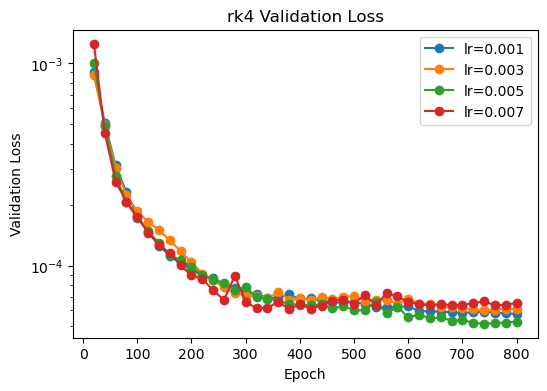

In [98]:
# # 4) Plotting with log-scale on the y-axis
# epochs = list(range(EVAL_INTERVAL, NUM_EPOCHS+1, EVAL_INTERVAL))

# for method in methods:
#     plt.figure(figsize=(6,4))
#     for lr in lrs:
#         plt.plot(
#             epochs,
#             results[(method, lr)],
#             marker='o',
#             label=f'lr={lr}'
#         )
#     plt.title(f"{method} Validation Loss")
#     plt.xlabel("Epoch")
#     plt.ylabel("Validation Loss")
#     plt.yscale('log')
#     plt.legend()
#     plt.show()

In [99]:
# # 5) Print final losses
# for (method, lr), losses in results.items():
#     print(f"{method:10s}  lr={lr:<7g}  → final val loss = {losses[-1]:.4e}")

rk4         lr=0.001    → final val loss = 5.7648e-05
rk4         lr=0.003    → final val loss = 6.0761e-05
rk4         lr=0.005    → final val loss = 5.2786e-05
rk4         lr=0.007    → final val loss = 6.5291e-05


Changing lr dropping strategy to ReduceLROnPlateau

Integrator:   0%|          | 0/1 [00:00<?, ?it/s]

LRs for rk4:   0%|          | 0/7 [00:00<?, ?it/s]

C:\Users\hande\anaconda3\envs\torch-gpu\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


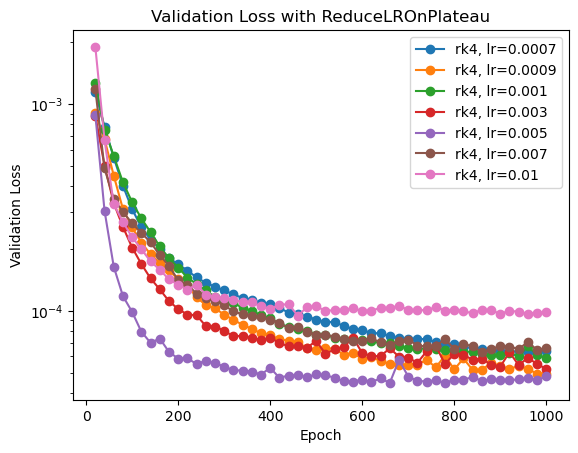

rk4         lr=0.0007   -> final val loss = 6.3795e-05
rk4         lr=0.0009   -> final val loss = 4.9389e-05
rk4         lr=0.001    -> final val loss = 5.9183e-05
rk4         lr=0.003    -> final val loss = 5.2125e-05
rk4         lr=0.005    -> final val loss = 4.8048e-05
rk4         lr=0.007    -> final val loss = 6.5915e-05
rk4         lr=0.01     -> final val loss = 9.7994e-05


In [171]:
# 1) Grid settings
methods    = ['rk4']
lrs        = [7e-4, 9e-4, 1e-3, 3e-3, 5e-3, 7e-3, 1e-2]
NUM_EPOCHS = 1000
EVAL_INTERVAL = 20  # how often to record val loss

# 2) Train+validate with ReduceLROnPlateau
def train_validate_plateau(method, lr):
    model = NeuralODEModel(3, 3, [100, 100], method).to(device)
    optim = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optim,
        mode='min',
        factor=0.8,
        patience=4,
        verbose=True
    )
    
    val_losses = []
    
    for epoch in range(1, NUM_EPOCHS + 1):
        # Training
        model.train()
        for b in train_loader:
            s, u, sn = b['state'].to(device), b['action'].to(device), b['next_state'].to(device)
            optim.zero_grad()
            loss = step_loss(model, s, u, sn)
            loss.backward()
            optim.step()
        
        # Validation & scheduler step
        if epoch % EVAL_INTERVAL == 0:
            model.eval()
            tot = 0.0
            with torch.no_grad():
                for b in val_loader:
                    s, u, sn = b['state'].to(device), b['action'].to(device), b['next_state'].to(device)
                    tot += step_loss(model, s, u, sn).item()
            val = tot / len(val_loader)
            val_losses.append(val)
            scheduler.step(val)

    # --- Save model after training
    model_path = os.path.join(save_dir, f"model_{method}_lr{lr}.pt")
    torch.save(model.state_dict(), model_path)
    print("Model saved to:", model_path, "as", f"model_{method}_lr{lr}.pt")
    
    return val_losses

# 3) Run sweep
results = {}
for method in tqdm(methods, desc="Integrator"):
    for lr in tqdm(lrs, desc=f"LRs for {method}", leave=False):
        vals = train_validate_plateau(method, lr)
        results[(method, lr)] = vals

# 4) Plotting
epochs = list(range(EVAL_INTERVAL, NUM_EPOCHS+1, EVAL_INTERVAL))
for (method, lr), losses in results.items():
    plt.plot(epochs, losses, marker='o', label=f'{method}, lr={lr}')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.title('Validation Loss with ReduceLROnPlateau')
plt.show()

# 5) Final loss printout
for (method, lr), losses in results.items():
    print(f"{method:10s}  lr={lr:<7g}  -> final val loss = {losses[-1]:.4e}")


Above is re-searching best model.

Models saved in single_rk4_models.
Load and check below:

In [190]:
# # 1) Config
# MODEL_DIR      = "single_rk4_models"
# MODEL_FILES    = ["model_rk4_lr0.003.pt"]
# VAL_BATCH_SIZE = 500   # ← exactly the batch_size you used when training

# # 3) Re-instantiate the exact same loss objects
# pose_loss = SE2PoseLoss(block_width=0.1, block_length=0.1)
# step_loss = SingleStepLoss(pose_loss)  # reduction='mean' by default

# # 4) Device
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # 5) Evaluate each saved model
# for fname in MODEL_FILES:
#     path = os.path.join(MODEL_DIR, fname)

#     # load model weights into a fresh instance
#     model = NeuralODEModel(
#         state_dim=3,
#         action_dim=3,
#         hidden_sizes=[100,100],
#         method="rk4"
#     )
#     model.load_state_dict(torch.load(path, map_location=device))
#     model.to(device).eval()

#     # accumulate per‐batch means, then average over the number of batches
#     total = 0.0
#     with torch.no_grad():
#         for batch in val_loader:
#             s, u, sn = (
#                 batch['state'].to(device),
#                 batch['action'].to(device),
#                 batch['next_state'].to(device)
#             )
#             total += step_loss(model, s, u, sn).item()

#     avg_loss = total / len(val_loader)
#     print(f"{fname:30s} -> val single-step loss = {avg_loss:.5e}")

model_rk4_lr0.003.pt           -> val single-step loss = 7.50219e-05


C:\Users\hande\AppData\Local\Temp\ipykernel_34680\2436383251.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=device)

Now test on dopri5 with the best hyperparams. Will take a long time.

Integrator:   0%|          | 0/1 [00:00<?, ?it/s]

LRs for dopri5:   0%|          | 0/1 [00:00<?, ?it/s]

dopri5, lr=0.003:   0%|          | 0/600 [00:00<?, ?it/s]

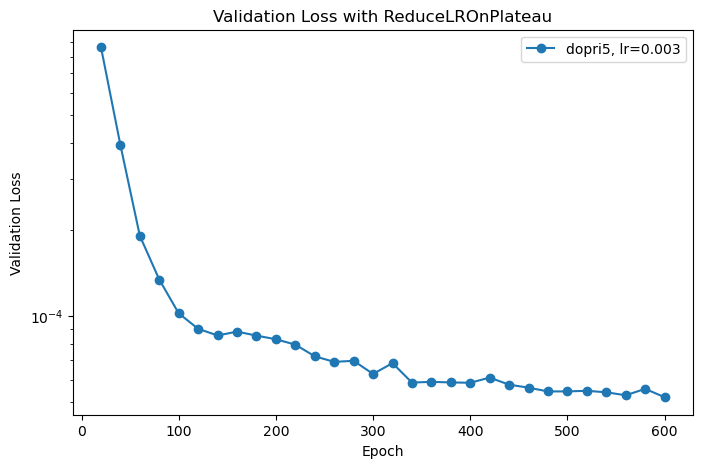

dopri5      lr=0.003    -> final val loss = 5.2073e-05


In [47]:
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# 1) Grid settings
methods    = ['dopri5']
lrs        = [3e-3]
NUM_EPOCHS = 600
EVAL_INTERVAL = 20  # how often to record val loss


# Make a directory to save models
save_dir = "single_dopri5_models"
os.makedirs(save_dir, exist_ok=True)

# 2) Train+validate with ReduceLROnPlateau and epoch-level tqdm
def train_validate_plateau(method, lr):
    model = NeuralODEModel(3, 3, [100, 100], method).to(device)
    optim = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optim,
        mode='min',
        factor=0.1,
        patience=4,
        verbose=True
    )
    
    val_losses = []
    epoch_iter = tqdm(range(1, NUM_EPOCHS + 1),
                      desc=f"{method}, lr={lr}",
                      leave=False)
    
    for epoch in epoch_iter:
        # Training
        model.train()
        for b in train_loader:
            s, u, sn = b['state'].to(device), b['action'].to(device), b['next_state'].to(device)
            optim.zero_grad()
            loss = step_loss(model, s, u, sn)
            loss.backward()
            optim.step()
        
        # Validation & scheduler step
        if epoch % EVAL_INTERVAL == 0:
            model.eval()
            tot = 0.0
            with torch.no_grad():
                for b in val_loader:
                    s, u, sn = b['state'].to(device), b['action'].to(device), b['next_state'].to(device)
                    tot += step_loss(model, s, u, sn).item()
            val = tot / len(val_loader)
            val_losses.append(val)
            scheduler.step(val)
            epoch_iter.set_postfix(val_loss=f"{val:.4e}")

    # --- Save model after training
    model_path = os.path.join(save_dir, f"model_{method}_lr{lr}.pt")
    torch.save(model.state_dict(), model_path)
    
    return val_losses

# 3) Run sweep with tqdm
results = {}
for method in tqdm(methods, desc="Integrator"):
    for lr in tqdm(lrs, desc=f"LRs for {method}", leave=False):
        vals = train_validate_plateau(method, lr)
        results[(method, lr)] = vals

        

# 4) Plotting with log-scale on the y-axis
epochs = list(range(EVAL_INTERVAL, NUM_EPOCHS+1, EVAL_INTERVAL))
plt.figure(figsize=(8,5))
for (method, lr), losses in results.items():
    plt.plot(epochs, losses, marker='o', label=f'{method}, lr={lr}')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.title('Validation Loss with ReduceLROnPlateau')
plt.show()

# 5) Final loss printout
for (method, lr), losses in results.items():
    print(f"{method:10s}  lr={lr:<7g}  -> final val loss = {losses[-1]:.4e}")


Model saved to single_dopri5_models

###  3.4 - Multiple_steps: A grid search of hyperparameters

#### 3.4.1 - Broad search

Due to time constraints, selecting only rk4 for now. Then do dopri5 for best hyperparams.

In [48]:
import itertools
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm
from torch import optim

from learning_state_dynamics import (
    NeuralODEModel,
    SE2PoseLoss,
    MultiStepLoss,
    process_data_multiple_step
)

In [147]:
# 1) Hyperparameter grid
lrs            = [1e-2, 1e-3, 1e-4]
# methods        = ['euler', 'rk4', 'dopri5']
# num_steps_list = [1, 4, 8]
methods        = ['rk4']
num_steps_list = [1, 4, 8]

NUM_EPOCHS = 500
BATCH_SIZE  = 500

Grid Search:   0%|          | 0/9 [00:00<?, ?config/s]

 Epochs :   0%|          | 0/500 [00:00<?, ?epoch/s]

 Epochs :   0%|          | 0/500 [00:00<?, ?epoch/s]

 Epochs :   0%|          | 0/500 [00:00<?, ?epoch/s]

 Epochs :   0%|          | 0/500 [00:00<?, ?epoch/s]

...

 Epochs :   0%|          | 0/500 [00:00<?, ?epoch/s]

 Epochs :   0%|          | 0/500 [00:00<?, ?epoch/s]

 Epochs :   0%|          | 0/500 [00:00<?, ?epoch/s]

 Epochs :   0%|          | 0/500 [00:00<?, ?epoch/s]

method          rk4                    
num_steps         1         4         8
lr                                     
0.0001     0.000321  0.005898  0.013813
0.0010     0.000074  0.000543  0.005251
0.0100     0.000069  0.000503  0.009222


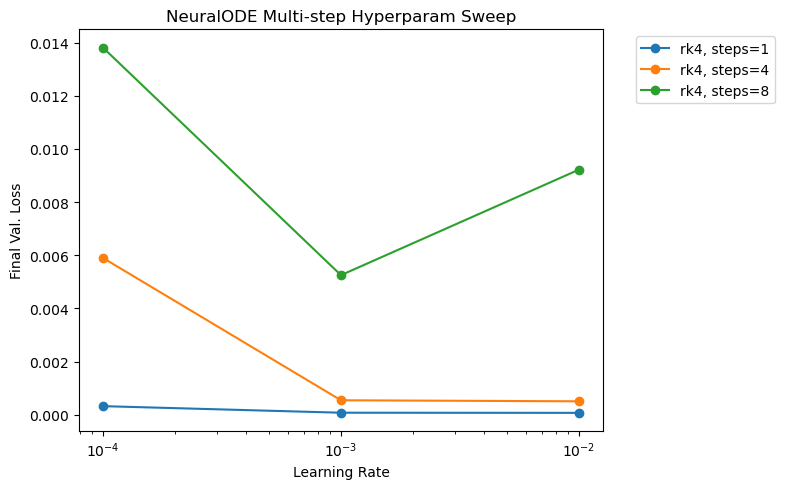

In [148]:
# 2) Load data once
collected_data = np.load('collected_data.npy', allow_pickle=True)

# 3) Device & base loss
device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pose_loss_fn = SE2PoseLoss(block_width=0.1, block_length=0.1)

# 4) Training + validation helper with epoch‐level tqdm
def train_and_validate(model, lr, train_loader, val_loader, step_loss_fn):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.to(device)
    
    train_losses = []
    val_losses   = []

    # inner bar for epochs
    epoch_bar = tqdm(range(1, NUM_EPOCHS+1),
                     desc=" Epochs ",
                     leave=False,
                     unit="epoch")
    
    for epoch in epoch_bar:
        # ---- training epoch
        model.train()
        total_tr = 0.0
        for batch in train_loader:
            s, u, s_next = (
                batch['state'].to(device),
                batch['action'].to(device),
                batch['next_state'].to(device),
            )
            optimizer.zero_grad()
            loss = step_loss_fn(model, s, u, s_next)
            loss.backward()
            optimizer.step()
            total_tr += loss.item()
        avg_tr = total_tr / len(train_loader)

        # ---- validation epoch
        model.eval()
        total_vl = 0.0
        with torch.no_grad():
            for batch in val_loader:
                s, u, s_next = (
                    batch['state'].to(device),
                    batch['action'].to(device),
                    batch['next_state'].to(device),
                )
                total_vl += step_loss_fn(model, s, u, s_next).item()
        avg_vl = total_vl / len(val_loader)

        train_losses.append(avg_tr)
        val_losses.append(avg_vl)

        # update inner bar
        epoch_bar.set_postfix(
            train=f"{avg_tr:.2e}",
            val=  f"{avg_vl:.2e}"
        )

    return train_losses, val_losses

# 5) Single outer tqdm over full grid
param_grid = list(itertools.product(lrs, methods, num_steps_list))
outer_bar = tqdm(param_grid,
                 total=len(param_grid),
                 desc="Grid Search",
                 unit="config")

results = []

for lr, method, num_steps in outer_bar:
    # a) build loaders
    train_loader, val_loader = process_data_multiple_step(
        collected_data,
        batch_size=BATCH_SIZE,
        num_steps=num_steps
    )

    # b) instantiate model + multi-step loss
    net       = NeuralODEModel(
                    state_dim=3,
                    action_dim=3,
                    hidden_sizes=[100,100],
                    method=method
                )
    step_loss = MultiStepLoss(pose_loss_fn, discount=0.9)

    # c) train & validate (shows inner epoch bar)
    train_losses, val_losses = train_and_validate(
        net, lr, train_loader, val_loader, step_loss
    )

    # d) record final val loss
    final_val = val_losses[-1]
    results.append({
        'method':    method,
        'lr':        lr,
        'num_steps': num_steps,
        'final_val': final_val
    })

    # e) update outer bar postfix
    outer_bar.set_postfix(
        meth=method,
        lr=lr,
        steps=num_steps,
        loss=f"{final_val:.2e}"
    )

# 6) Summarize
df = pd.DataFrame(results)
pivot = df.pivot_table(
    index='lr',
    columns=['method','num_steps'],
    values='final_val'
)
print(pivot)

# 7) plot
plt.figure(figsize=(8,5))
for m in methods:
    for ns in num_steps_list:
        sel = df[(df.method==m)&(df.num_steps==ns)]
        plt.plot(sel.lr, sel.final_val, '-o', label=f"{m}, steps={ns}")
plt.xscale('log')
plt.xlabel('Learning Rate')
plt.ylabel('Final Val. Loss')
plt.title('NeuralODE Multi-step Hyperparam Sweep')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

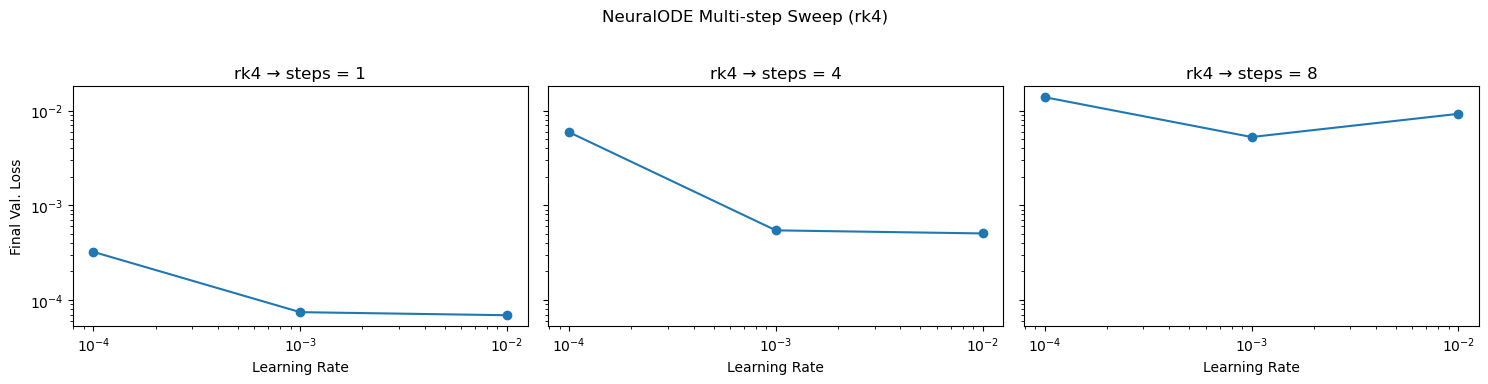

In [155]:
# 7) Plot one figure per method (y-axis log)
fig, axs = plt.subplots(
    1, len(num_steps_list),
    figsize=(15, 4),
    sharey=True
)

for ax, ns in zip(axs, num_steps_list):
    # select only rk4 & this horizon
    sel = df[(df.method == 'rk4') & (df.num_steps == ns)]
    ax.plot(
        sel.lr,
        sel.final_val,
        marker='o',
        linestyle='-'
    )
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(f"rk4 → steps = {ns}")
    ax.set_xlabel("Learning Rate")
axs[0].set_ylabel("Final Val. Loss")  # only need y-label on first

plt.suptitle("NeuralODE Multi-step Sweep (rk4)")  # overall title
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

From this, the suspiction is more epochs needed for more steps. Analyze only steps 1 and 4 for now.

#### 3.4.2 RK4, step 1:

In [49]:
# 1) Grid settings
methods     = ['rk4']
lrs         = [7e-4, 1e-3, 3e-3, 5e-3, 7e-3]
num_steps   = 1
NUM_EPOCHS  = 500
EVAL_INTERVAL = 20   # record val loss every 20 epochs
BATCH_SIZE  = 500

device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pose_loss_fn = SE2PoseLoss(block_width=0.1, block_length=0.1)

# Make a directory to save models
save_dir = "multiple_rk4_models"
os.makedirs(save_dir, exist_ok=True)

# 2) Train+validate that records intermediate multi-step losses
def train_validate(method, lr):
    # build multi-step dataloaders
    train_loader, val_loader = process_data_multiple_step(
        collected_data,
        batch_size=BATCH_SIZE,
        num_steps=num_steps
    )
    # instantiate model & optimizer
    model = NeuralODEModel(
        state_dim=3,
        action_dim=3,
        hidden_sizes=[100,100],
        method=method
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    step_loss_fn = MultiStepLoss(pose_loss_fn, discount=0.9)

    val_losses = []
    # <-- wrap the epoch loop in tqdm
    for epoch in tqdm(
        range(1, NUM_EPOCHS+1),
        desc=f"Epochs @ lr={lr:.1e}",
        leave=False,
        unit="epoch"
    ):
        # --- training step
        model.train()
        for b in train_loader:
            s, u, sn = (
                b['state'].to(device),
                b['action'].to(device),
                b['next_state'].to(device),
            )
            optimizer.zero_grad()
            loss = step_loss_fn(model, s, u, sn)
            loss.backward()
            optimizer.step()

        # --- validation at interval
        if epoch % EVAL_INTERVAL == 0:
            model.eval()
            tot = 0.0
            with torch.no_grad():
                for b in val_loader:
                    s, u, sn = (
                        b['state'].to(device),
                        b['action'].to(device),
                        b['next_state'].to(device),
                    )
                    tot += step_loss_fn(model, s, u, sn).item()
            val_losses.append(tot / len(val_loader))

    # --- Save model after training
    model_path = os.path.join(save_dir, f"model_{method}_steps{num_steps}_lr{lr}.pt")
    torch.save(model.state_dict(), model_path)
        
    return val_losses

# 3) Run sweep with tqdm
results = {}
for method in tqdm(methods, desc="Integrator"):
    for lr in tqdm(lrs, desc=f"LRs for {method}", leave=False):
        vals = train_validate(method, lr)
        results[(method, lr)] = vals



# --- after your grid‐search loop
print("\nFinal validation losses:")
for (method, lr), val_losses in results.items():
    final = val_losses[-1]
    print(f"{method:4s} | lr={lr:<7g} → final val loss = {final:.4e}")

Integrator:   0%|          | 0/1 [00:00<?, ?it/s]

LRs for rk4:   0%|          | 0/5 [00:00<?, ?it/s]

Epochs @ lr=7.0e-04:   0%|          | 0/500 [00:00<?, ?epoch/s]

Epochs @ lr=1.0e-03:   0%|          | 0/500 [00:00<?, ?epoch/s]

Epochs @ lr=3.0e-03:   0%|          | 0/500 [00:00<?, ?epoch/s]

Epochs @ lr=5.0e-03:   0%|          | 0/500 [00:00<?, ?epoch/s]

Epochs @ lr=7.0e-03:   0%|          | 0/500 [00:00<?, ?epoch/s]


Final validation losses:
rk4  | lr=0.0007  → final val loss = 7.3693e-05
rk4  | lr=0.001   → final val loss = 4.9229e-05
rk4  | lr=0.003   → final val loss = 5.9223e-05
rk4  | lr=0.005   → final val loss = 8.2219e-05
rk4  | lr=0.007   → final val loss = 7.6808e-05


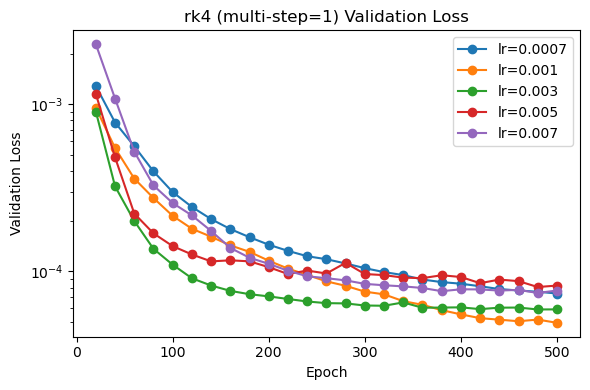

In [50]:
# 4) Plotting with log-log scales, one subplot per num_steps (here num_steps=1)
epochs = list(range(EVAL_INTERVAL, NUM_EPOCHS+1, EVAL_INTERVAL))

fig, ax = plt.subplots(figsize=(6,4))
for lr in lrs:
    ax.plot(
        epochs,
        results[('rk4', lr)],
        marker='o',
        label=f'lr={lr}'
    )
ax.set_title(f"rk4 (multi‐step={num_steps}) Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Loss")
ax.set_xscale('linear')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()


With Plateau lr reduction strategy:

In [51]:
# 1) Grid settings
methods     = ['rk4']
lrs         = [7e-4, 1e-3, 3e-3, 5e-3, 7e-3]
num_steps   = 1
NUM_EPOCHS  = 1000
EVAL_INTERVAL = 20   # record val loss every 20 epochs
BATCH_SIZE  = 500

device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pose_loss_fn = SE2PoseLoss(block_width=0.1, block_length=0.1)

# Make a directory to save models
save_dir = "multiple_rk4_models"
os.makedirs(save_dir, exist_ok=True)

# 2) Train+validate with ReduceLROnPlateau
def train_validate(method, lr):
    # build multi-step dataloaders
    train_loader, val_loader = process_data_multiple_step(
        collected_data,
        batch_size=BATCH_SIZE,
        num_steps=num_steps
    )

    # instantiate model, optimizer & scheduler
    model     = NeuralODEModel(3, 3, [100,100], method).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.1,
        patience=4,
        verbose=True
    )
    step_loss_fn = MultiStepLoss(pose_loss_fn, discount=0.9)

    val_losses = []
    # inner bar for epochs
    epoch_bar = tqdm(
        range(1, NUM_EPOCHS+1),
        desc=f"Epochs @ lr={lr:.1e}",
        leave=False,
        unit="epoch"
    )
    for epoch in epoch_bar:
        # --- train
        model.train()
        for b in train_loader:
            s, u, sn = (
                b['state'].to(device),
                b['action'].to(device),
                b['next_state'].to(device),
            )
            optimizer.zero_grad()
            loss = step_loss_fn(model, s, u, sn)
            loss.backward()
            optimizer.step()

        # --- validate & step scheduler at interval
        if epoch % EVAL_INTERVAL == 0:
            model.eval()
            tot = 0.0
            with torch.no_grad():
                for b in val_loader:
                    s, u, sn = (
                        b['state'].to(device),
                        b['action'].to(device),
                        b['next_state'].to(device),
                    )
                    tot += step_loss_fn(model, s, u, sn).item()
            avg_val = tot / len(val_loader)
            val_losses.append(avg_val)

            # tell scheduler how we did
            scheduler.step(avg_val)

            # display train/val/lr
            current_lr = optimizer.param_groups[0]['lr']
            epoch_bar.set_postfix({
                'val': f"{avg_val:.2e}",
                'lr':  f"{current_lr:.1e}"
            })

    # --- Save model after training
    model_path = os.path.join(save_dir, f"model_{method}_steps{num_steps}_lr{lr}.pt")
    torch.save(model.state_dict(), model_path)

    return val_losses

# 3) Run sweep with tqdm
results = {}
for method in tqdm(methods, desc="Integrator"):
    for lr in tqdm(lrs, desc=f"LRs for {method}", leave=False):
        vals = train_validate(method, lr)
        results[(method, lr)] = vals

        


# --- after your grid‐search loop
print("\nFinal validation losses:")
for (method, lr), val_losses in results.items():
    final = val_losses[-1]
    print(f"{method:4s} | lr={lr:<7g} → final val loss = {final:.4e}")

Integrator:   0%|          | 0/1 [00:00<?, ?it/s]

LRs for rk4:   0%|          | 0/5 [00:00<?, ?it/s]

Epochs @ lr=7.0e-04:   0%|          | 0/1000 [00:00<?, ?epoch/s]

Epochs @ lr=1.0e-03:   0%|          | 0/1000 [00:00<?, ?epoch/s]

Epochs @ lr=3.0e-03:   0%|          | 0/1000 [00:00<?, ?epoch/s]

Epochs @ lr=5.0e-03:   0%|          | 0/1000 [00:00<?, ?epoch/s]

Epochs @ lr=7.0e-03:   0%|          | 0/1000 [00:00<?, ?epoch/s]


Final validation losses:
rk4  | lr=0.0007  → final val loss = 5.1567e-05
rk4  | lr=0.001   → final val loss = 4.5713e-05
rk4  | lr=0.003   → final val loss = 1.2468e-04
rk4  | lr=0.005   → final val loss = 4.9799e-05
rk4  | lr=0.007   → final val loss = 6.5149e-05


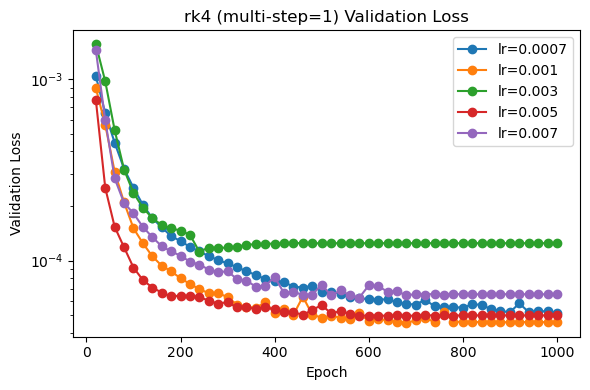

In [52]:
# 4) Plotting with log-log scales, one subplot per num_steps (here num_steps=1)
epochs = list(range(EVAL_INTERVAL, NUM_EPOCHS+1, EVAL_INTERVAL))

fig, ax = plt.subplots(figsize=(6,4))
for lr in lrs:
    ax.plot(
        epochs,
        results[('rk4', lr)],
        marker='o',
        label=f'lr={lr}'
    )
ax.set_title(f"rk4 (multi‐step={num_steps}) Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Loss")
ax.set_xscale('linear')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()


#### 3.4.3 RK4, step 4:

Directly using ReduceLROnPlateau. Increased NUM_EPOCHS from 1000 to 1500.

In [53]:
# 1) Grid settings
methods     = ['rk4']
lrs         = [7e-4, 1e-3, 3e-3, 5e-3, 7e-3]
num_steps   = 4
NUM_EPOCHS  = 1500
EVAL_INTERVAL = 20   # record val loss every 20 epochs
BATCH_SIZE  = 500

device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pose_loss_fn = SE2PoseLoss(block_width=0.1, block_length=0.1)

# Make a directory to save models
save_dir = "multiple_rk4_models"
os.makedirs(save_dir, exist_ok=True)

# 2) Train+validate with ReduceLROnPlateau
def train_validate(method, lr):
    # build multi-step dataloaders
    train_loader, val_loader = process_data_multiple_step(
        collected_data,
        batch_size=BATCH_SIZE,
        num_steps=num_steps
    )

    # instantiate model, optimizer & scheduler
    model     = NeuralODEModel(3, 3, [100,100], method).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.1,
        patience=4,
        verbose=True
    )
    step_loss_fn = MultiStepLoss(pose_loss_fn, discount=0.9)

    val_losses = []
    # inner bar for epochs
    epoch_bar = tqdm(
        range(1, NUM_EPOCHS+1),
        desc=f"Epochs @ lr={lr:.1e}",
        leave=False,
        unit="epoch"
    )
    for epoch in epoch_bar:
        # --- train
        model.train()
        for b in train_loader:
            s, u, sn = (
                b['state'].to(device),
                b['action'].to(device),
                b['next_state'].to(device),
            )
            optimizer.zero_grad()
            loss = step_loss_fn(model, s, u, sn)
            loss.backward()
            optimizer.step()

        # --- validate & step scheduler at interval
        if epoch % EVAL_INTERVAL == 0:
            model.eval()
            tot = 0.0
            with torch.no_grad():
                for b in val_loader:
                    s, u, sn = (
                        b['state'].to(device),
                        b['action'].to(device),
                        b['next_state'].to(device),
                    )
                    tot += step_loss_fn(model, s, u, sn).item()
            avg_val = tot / len(val_loader)
            val_losses.append(avg_val)

            # tell scheduler how we did
            scheduler.step(avg_val)

            # display train/val/lr
            current_lr = optimizer.param_groups[0]['lr']
            epoch_bar.set_postfix({
                'val': f"{avg_val:.2e}",
                'lr':  f"{current_lr:.1e}"
            })

    # --- Save model after training
    model_path = os.path.join(save_dir, f"model_{method}_steps{num_steps}_lr{lr}.pt")
    torch.save(model.state_dict(), model_path)

    return val_losses

# 3) Run sweep with tqdm
results = {}
for method in tqdm(methods, desc="Integrator"):
    for lr in tqdm(lrs, desc=f"LRs for {method}", leave=False):
        vals = train_validate(method, lr)
        results[(method, lr)] = vals

# --- after your grid‐search loop
print("\nFinal validation losses:")
for (method, lr), val_losses in results.items():
    final = val_losses[-1]
    print(f"{method:4s} | lr={lr:<7g} → final val loss = {final:.4e}")

Integrator:   0%|          | 0/1 [00:00<?, ?it/s]

LRs for rk4:   0%|          | 0/5 [00:00<?, ?it/s]

Epochs @ lr=7.0e-04:   0%|          | 0/1500 [00:00<?, ?epoch/s]

Epochs @ lr=1.0e-03:   0%|          | 0/1500 [00:00<?, ?epoch/s]

Epochs @ lr=3.0e-03:   0%|          | 0/1500 [00:00<?, ?epoch/s]

Epochs @ lr=5.0e-03:   0%|          | 0/1500 [00:00<?, ?epoch/s]

Epochs @ lr=7.0e-03:   0%|          | 0/1500 [00:00<?, ?epoch/s]


Final validation losses:
rk4  | lr=0.0007  → final val loss = 2.4992e-04
rk4  | lr=0.001   → final val loss = 4.9732e-04
rk4  | lr=0.003   → final val loss = 2.0823e-04
rk4  | lr=0.005   → final val loss = 2.8118e-04
rk4  | lr=0.007   → final val loss = 2.5930e-04


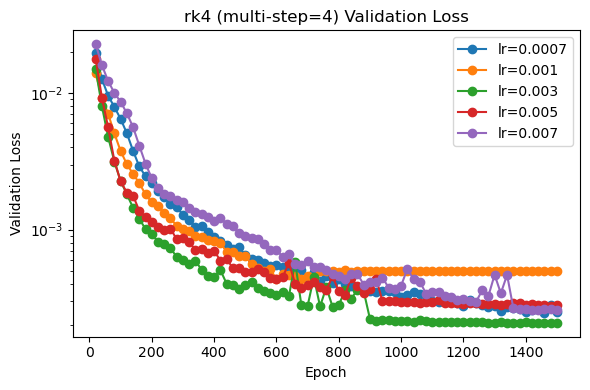

In [54]:
# 4) Plotting with log-log scales, one subplot per num_steps (here num_steps=1)
epochs = list(range(EVAL_INTERVAL, NUM_EPOCHS+1, EVAL_INTERVAL))

fig, ax = plt.subplots(figsize=(6,4))
for lr in lrs:
    ax.plot(
        epochs,
        results[('rk4', lr)],
        marker='o',
        label=f'lr={lr}'
    )
ax.set_title(f"rk4 (multi‐step={num_steps}) Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Loss")
ax.set_xscale('linear')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()

Models saved in multiple_rk4_models

#### 3.4.4 DOPRI5, step 4:

In [59]:
# 1) Grid settings
methods     = ['dopri5']
lrs         = [1e-2]
num_steps   = 4
NUM_EPOCHS  = 1000
EVAL_INTERVAL = 20   # record val loss every 20 epochs
BATCH_SIZE  = 500

device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pose_loss_fn = SE2PoseLoss(block_width=0.1, block_length=0.1)

# Make a directory to save models
save_dir = "multiple_dopri5_models"
os.makedirs(save_dir, exist_ok=True)

# 2) Train+validate with ReduceLROnPlateau
def train_validate(method, lr):
    # build multi-step dataloaders
    train_loader, val_loader = process_data_multiple_step(
        collected_data,
        batch_size=BATCH_SIZE,
        num_steps=num_steps
    )

    # instantiate model, optimizer & scheduler
    model     = NeuralODEModel(3, 3, [100,100], method).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.1,
        patience=4,
        verbose=True
    )
    step_loss_fn = MultiStepLoss(pose_loss_fn, discount=0.9)

    val_losses = []
    # inner bar for epochs
    epoch_bar = tqdm(
        range(1, NUM_EPOCHS+1),
        desc=f"Epochs @ lr={lr:.1e}",
        leave=False,
        unit="epoch"
    )
    for epoch in epoch_bar:
        # --- train
        model.train()
        for b in train_loader:
            s, u, sn = (
                b['state'].to(device),
                b['action'].to(device),
                b['next_state'].to(device),
            )
            optimizer.zero_grad()
            loss = step_loss_fn(model, s, u, sn)
            loss.backward()
            optimizer.step()

        # --- validate & step scheduler at interval
        if epoch % EVAL_INTERVAL == 0:
            model.eval()
            tot = 0.0
            with torch.no_grad():
                for b in val_loader:
                    s, u, sn = (
                        b['state'].to(device),
                        b['action'].to(device),
                        b['next_state'].to(device),
                    )
                    tot += step_loss_fn(model, s, u, sn).item()
            avg_val = tot / len(val_loader)
            val_losses.append(avg_val)

            # tell scheduler how we did
            scheduler.step(avg_val)

            # display train/val/lr
            current_lr = optimizer.param_groups[0]['lr']
            epoch_bar.set_postfix({
                'val': f"{avg_val:.2e}",
                'lr':  f"{current_lr:.1e}"
            })

    # --- Save model after training
    model_path = os.path.join(save_dir, f"model_{method}_steps{num_steps}_lr{lr}.pt")
    torch.save(model.state_dict(), model_path)

    return val_losses

# 3) Run sweep with tqdm
results = {}
for method in tqdm(methods, desc="Integrator"):
    for lr in tqdm(lrs, desc=f"LRs for {method}", leave=False):
        vals = train_validate(method, lr)
        results[(method, lr)] = vals

# --- after your grid‐search loop
print("\nFinal validation losses:")
for (method, lr), val_losses in results.items():
    final = val_losses[-1]
    print(f"{method:4s} | lr={lr:<7g} → final val loss = {final:.4e}")

Integrator:   0%|          | 0/1 [00:00<?, ?it/s]

LRs for dopri5:   0%|          | 0/1 [00:00<?, ?it/s]

Epochs @ lr=1.0e-02:   0%|          | 0/1000 [00:00<?, ?epoch/s]


Final validation losses:
dopri5 | lr=0.01    → final val loss = 7.8383e-04


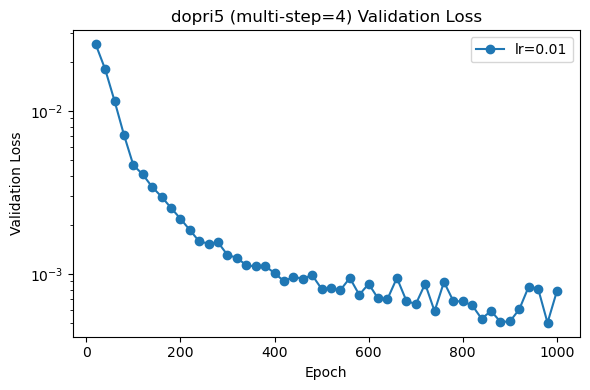

In [60]:
# 4) Plotting with log-log scales, one subplot per num_steps (here num_steps=1)
epochs = list(range(EVAL_INTERVAL, NUM_EPOCHS+1, EVAL_INTERVAL))

fig, ax = plt.subplots(figsize=(6,4))
for lr in lrs:
    ax.plot(
        epochs,
        results[('dopri5', lr)],
        marker='o',
        label=f'lr={lr}'
    )
ax.set_title(f"dopri5 (multi‐step={num_steps}) Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Loss")
ax.set_xscale('linear')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()

In [63]:
print(results[('dopri5', lr)][-2])

0.0005003912374377251


The lowest loss obtained was 5e-4.  
There seems to be a trend still going down at 1000th epoch, compared to in rk4 that already converged at 1000th epoch.

### 3.5 - Multistep vs Single Step Loss
In this section we will compare the performance of the multi-step and single-step loss for the residual dynamics model with test data that we provide you.

You should see that the multi-step trained model performs similarly to the single-step trained model when evaluated on the single-step loss. As above, this loss should be below $5 \times 10^{-4}$. 

You might notice that the multi-step loss in this example does not actually lead to better performance for multi-step prediction. This is nothing to be concerned about. Whether or not a multi-step loss is required for good multi-step performance depends on the specific problem. 


In [79]:
# Load models

# 1: helper function to instantiate & load a NeuralODEModel
def load_neuralode(state_dim, action_dim, hidden_sizes, method, path):
    """
    Instantiate a NeuralODEModel with given architecture and load weights from path.
    Returns the model in eval mode.
    """
    model = NeuralODEModel(state_dim, action_dim, hidden_sizes, method)
    state_dict = torch.load(path, map_location="cpu")
    model.load_state_dict(state_dict)
    model.eval()
    print(f"✅ Loaded {method} model from `{path}`")
    return model

# 2: set architecture parameters & checkpoint paths
state_dim    = 3
action_dim   = 3
hidden_sizes = [100, 100]
method       = "rk4"

single_path   = "single_rk4_models/model_rk4_lr0.007.pt"
multiple_path = "multiple_rk4_models/model_rk4_steps4_lr0.003.pt"

# 3: load both models
single_model   = load_neuralode(state_dim, action_dim, hidden_sizes, method, single_path)
multiple_model = load_neuralode(state_dim, action_dim, hidden_sizes, method, multiple_path)

# 4: inspect parameter shapes for a quick sanity check
print("\nSingle-step NeuralODE parameters:")
for name, param in single_model.named_parameters():
    print(f"  {name:30s} => {tuple(param.shape)}")

print("\nMulti-step NeuralODE parameters:")
for name, param in multiple_model.named_parameters():
    print(f"  {name:30s} => {tuple(param.shape)}")


✅ Loaded rk4 model from `single_rk4_models/model_rk4_lr0.007.pt`
✅ Loaded rk4 model from `multiple_rk4_models/model_rk4_steps4_lr0.003.pt`

Single-step NeuralODE parameters:
  func.net.0.weight              => (100, 6)
  func.net.0.bias                => (100,)
  func.net.2.weight              => (100, 100)
  func.net.2.bias                => (100,)
  func.net.4.weight              => (3, 100)
  func.net.4.bias                => (3,)

Multi-step NeuralODE parameters:
  func.net.0.weight              => (100, 6)
  func.net.0.bias                => (100,)
  func.net.2.weight              => (100, 100)
  func.net.2.bias                => (100,)
  func.net.4.weight              => (3, 100)
  func.net.4.bias                => (3,)


C:\Users\hande\AppData\Local\Temp\ipykernel_34680\400760332.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(path, map_location="cpu")


In [80]:
# Prepare validation datasets and loaders
val_dataset = SingleStepDynamicsDataset(
    np.load('validation_data.npy', allow_pickle=True)
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=len(val_dataset),
    shuffle=False
)

num_steps = 4
val_multistep_dataset = MultiStepDynamicsDataset(
    np.load('validation_data.npy', allow_pickle=True),
    num_steps=num_steps
)
val_multistep_loader = torch.utils.data.DataLoader(
    val_multistep_dataset,
    batch_size=len(val_multistep_dataset),
    shuffle=False
)

# Instantiate loss functions
pose_loss_fn        = SE2PoseLoss(block_width=0.1, block_length=0.1)
single_step_loss_fn = SingleStepLoss(pose_loss_fn)
multi_step_loss_fn  = MultiStepLoss(pose_loss_fn, discount=1)


# Compute single-step validation losses
single_loss_single_model = 0.0
single_loss_multi_model  = 0.0

for batch in val_loader:
    s, u, s_next = batch['state'], batch['action'], batch['next_state']
    
    single_loss_single_model += single_step_loss_fn(
        single_model, s, u, s_next
    ).item()
    
    single_loss_multi_model += single_step_loss_fn(
        multiple_model, s, u, s_next
    ).item()

print(f"Validation single-step loss (single_model): {single_loss_single_model:.6e}")
print(f"Validation single-step loss (multiple(4-step)_model): {single_loss_multi_model:.6e}")

# Compute multi-step validation losses
multi_loss_single_model = 0.0
multi_loss_multi_model  = 0.0

for batch in val_multistep_loader:
    s, u_seq, s_seq = batch['state'], batch['action'], batch['next_state']
    
    multi_loss_single_model += multi_step_loss_fn(
        single_model, s, u_seq, s_seq
    ).item()
    
    multi_loss_multi_model += multi_step_loss_fn(
        multiple_model, s, u_seq, s_seq
    ).item()

# Normalize by number of steps
multi_loss_single_model /= num_steps
multi_loss_multi_model  /= num_steps

print(f"Validation multi-step loss (single_model): {multi_loss_single_model:.6e}")
print(f"Validation multi-step loss (multiple(4-step)_model): {multi_loss_multi_model:.6e}")

Validation single-step loss (single_model): 7.008172e-05
Validation single-step loss (multiple(4-step)_model): 8.895261e-05
Validation multi-step loss (single_model): 2.097441e-04
Validation multi-step loss (multiple(4-step)_model): 2.496874e-04


**Above is using step4 model, now also check step1 model.**

In [83]:
single_path   = "single_rk4_models/model_rk4_lr0.007.pt"
# changed to steps1
multiple_path = "multiple_rk4_models/model_rk4_steps1_lr0.001.pt"

# 3: load both models
single_model   = load_neuralode(state_dim, action_dim, hidden_sizes, method, single_path)
multiple_model = load_neuralode(state_dim, action_dim, hidden_sizes, method, multiple_path)

# 4: inspect parameter shapes for a quick sanity check
print("\nSingle-step NeuralODE parameters:")
for name, param in single_model.named_parameters():
    print(f"  {name:30s} => {tuple(param.shape)}")

print("\nMulti-step NeuralODE parameters:")
for name, param in multiple_model.named_parameters():
    print(f"  {name:30s} => {tuple(param.shape)}")


✅ Loaded rk4 model from `single_rk4_models/model_rk4_lr0.007.pt`
✅ Loaded rk4 model from `multiple_rk4_models/model_rk4_steps1_lr0.001.pt`

Single-step NeuralODE parameters:
  func.net.0.weight              => (100, 6)
  func.net.0.bias                => (100,)
  func.net.2.weight              => (100, 100)
  func.net.2.bias                => (100,)
  func.net.4.weight              => (3, 100)
  func.net.4.bias                => (3,)

Multi-step NeuralODE parameters:
  func.net.0.weight              => (100, 6)
  func.net.0.bias                => (100,)
  func.net.2.weight              => (100, 100)
  func.net.2.bias                => (100,)
  func.net.4.weight              => (3, 100)
  func.net.4.bias                => (3,)


C:\Users\hande\AppData\Local\Temp\ipykernel_34680\400760332.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(path, map_location="cpu")


In [82]:
num_steps = 1
val_multistep_dataset = MultiStepDynamicsDataset(
    np.load('validation_data.npy', allow_pickle=True),
    num_steps=num_steps
)
val_multistep_loader = torch.utils.data.DataLoader(
    val_multistep_dataset,
    batch_size=len(val_multistep_dataset),
    shuffle=False
)

# Instantiate loss functions
pose_loss_fn        = SE2PoseLoss(block_width=0.1, block_length=0.1)
single_step_loss_fn = SingleStepLoss(pose_loss_fn)
multi_step_loss_fn  = MultiStepLoss(pose_loss_fn, discount=1)


# Compute single-step validation losses
single_loss_single_model = 0.0
single_loss_multi_model  = 0.0

for batch in val_loader:
    s, u, s_next = batch['state'], batch['action'], batch['next_state']
    
    single_loss_single_model += single_step_loss_fn(
        single_model, s, u, s_next
    ).item()
    
    single_loss_multi_model += single_step_loss_fn(
        multiple_model, s, u, s_next
    ).item()

print(f"Validation single-step loss (single_model): {single_loss_single_model:.6e}")
print(f"Validation single-step loss (multiple(4-step)_model): {single_loss_multi_model:.6e}")

# Compute multi-step validation losses
multi_loss_single_model = 0.0
multi_loss_multi_model  = 0.0

for batch in val_multistep_loader:
    s, u_seq, s_seq = batch['state'], batch['action'], batch['next_state']
    
    multi_loss_single_model += multi_step_loss_fn(
        single_model, s, u_seq, s_seq
    ).item()
    
    multi_loss_multi_model += multi_step_loss_fn(
        multiple_model, s, u_seq, s_seq
    ).item()

# Normalize by number of steps
multi_loss_single_model /= num_steps
multi_loss_multi_model  /= num_steps

print(f"Validation multi-step loss (single_model): {multi_loss_single_model:.6e}")
print(f"Validation multi-step loss (multiple(4-step)_model): {multi_loss_multi_model:.6e}")

Validation single-step loss (single_model): 7.008172e-05
Validation single-step loss (multiple(4-step)_model): 7.974258e-05
Validation multi-step loss (single_model): 7.008172e-05
Validation multi-step loss (multiple(4-step)_model): 7.974258e-05


### 3.6 Network Expressivity Test

Single step, rk4, lr = 0.003

In [106]:
# Grid settings

methods = ['rk4']
hidden_sizes_list = [
    [50, 50],
    [100, 100],
    [200, 200],
    [100, 100, 100]
]
lrs = [3e-3]

NUM_EPOCHS = 1000
EVAL_INTERVAL = 20  # record val loss every 20 epochs

save_dir = "expressivity_models"
os.makedirs(save_dir, exist_ok=True)

In [107]:
def train_validate_plateau(method, lr, hidden_sizes):
    # instantiate model with varying expressivity
    model = NeuralODEModel(
        state_dim=3,
        action_dim=3,
        hidden_sizes=hidden_sizes,
        method=method
    ).to(device)
    optim = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optim, mode='min', factor=0.1, patience=4, verbose=False
    )
    val_losses = []

    # wrap epochs in tqdm for progress reporting
    desc = f"hs={hidden_sizes}, lr={lr}"
    epoch_iter = tqdm(
        range(1, NUM_EPOCHS + 1),
        desc=desc,
        unit="epoch",
        leave=False
    )
    
    for epoch in epoch_iter:
        # training
        model.train()
        for b in train_loader:
            s, u, sn = (b['state'].to(device),
                        b['action'].to(device),
                        b['next_state'].to(device))
            optim.zero_grad()
            loss = step_loss(model, s, u, sn)
            loss.backward()
            optim.step()
        
        # validation & LR scheduling
        if epoch % EVAL_INTERVAL == 0:
            model.eval()
            tot = 0.0
            with torch.no_grad():
                for b in val_loader:
                    s, u, sn = (b['state'].to(device),
                                b['action'].to(device),
                                b['next_state'].to(device))
                    tot += step_loss(model, s, u, sn).item()
            val = tot / len(val_loader)
            val_losses.append(val)
            scheduler.step(val)
            # update progress bar postfix
            epoch_iter.set_postfix(val=f"{val:.4e}")
    
    # save model
    hs_str = "x".join(map(str, hidden_sizes))
    model_path = os.path.join(
        save_dir,
        f"model_{method}_{hs_str}_lr{lr}.pt"
    )
    torch.save(model.state_dict(), model_path)
    
    return val_losses

In [108]:
# Run the sweep over width/depth and learning rates
results = {}
for hidden_sizes in tqdm(hidden_sizes_list, desc="Architectures"):
    for lr in tqdm(lrs, desc=f"LRs (hs={hidden_sizes})", leave=False):
        losses = train_validate_plateau('rk4', lr, hidden_sizes)
        results[(tuple(hidden_sizes), lr)] = losses

Architectures:   0%|          | 0/4 [00:00<?, ?it/s]

LRs (hs=[50, 50]):   0%|          | 0/1 [00:00<?, ?it/s]

hs=[50, 50], lr=0.003:   0%|          | 0/1000 [00:00<?, ?epoch/s]

LRs (hs=[100, 100]):   0%|          | 0/1 [00:00<?, ?it/s]

hs=[100, 100], lr=0.003:   0%|          | 0/1000 [00:00<?, ?epoch/s]

LRs (hs=[200, 200]):   0%|          | 0/1 [00:00<?, ?it/s]

hs=[200, 200], lr=0.003:   0%|          | 0/1000 [00:00<?, ?epoch/s]

LRs (hs=[100, 100, 100]):   0%|          | 0/1 [00:00<?, ?it/s]

hs=[100, 100, 100], lr=0.003:   0%|          | 0/1000 [00:00<?, ?epoch/s]

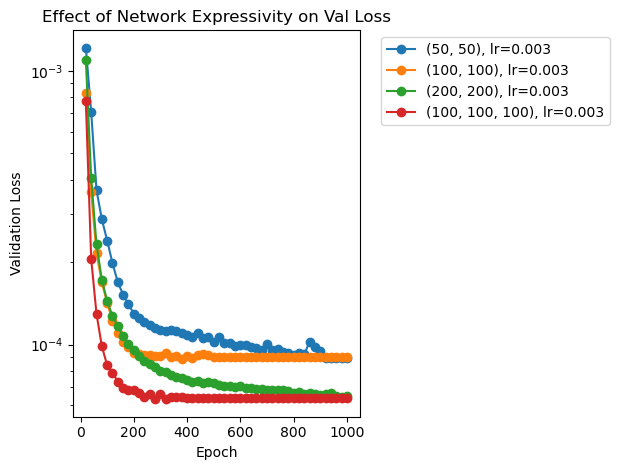

In [109]:
# Plot validation-loss curves
epochs = list(range(EVAL_INTERVAL, NUM_EPOCHS+1, EVAL_INTERVAL))
for (hidden_sizes, lr), losses in results.items():
    label = f"{hidden_sizes}, lr={lr}"
    plt.plot(epochs, losses, '-o', label=label)
plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.title("Effect of Network Expressivity on Val Loss")
plt.tight_layout()
plt.show()

In [110]:
# Print final losses
for (hidden_sizes, lr), losses in results.items():
    print(f"hidden={hidden_sizes}, lr={lr} → final val loss = {losses[-1]:.4e}")

hidden=(50, 50), lr=0.003 → final val loss = 8.9277e-05
hidden=(100, 100), lr=0.003 → final val loss = 9.0080e-05
hidden=(200, 200), lr=0.003 → final val loss = 6.4856e-05
hidden=(100, 100, 100), lr=0.003 → final val loss = 6.3795e-05


**More complicated = better?**

In [111]:
# Grid settings

methods = ['rk4']
hidden_sizes_list = [
    [300, 300],          # even wider
    [200, 200, 200],     # deeper + wide
    [100, 200, 100],     # “hourglass” shape  
    [50, 100, 50],       # narrow–wide–narrow  
    [100, 100, 100, 100],# 4 layers of 100  
    [150],               # single layer of moderate width
]
lrs = [3e-3]

NUM_EPOCHS = 1000
EVAL_INTERVAL = 20  # record val loss every 20 epochs

save_dir = "expressivity_models"
os.makedirs(save_dir, exist_ok=True)

In [112]:
def train_validate_plateau(method, lr, hidden_sizes):
    # instantiate model with varying expressivity
    model = NeuralODEModel(
        state_dim=3,
        action_dim=3,
        hidden_sizes=hidden_sizes,
        method=method
    ).to(device)
    optim = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optim, mode='min', factor=0.1, patience=4, verbose=False
    )
    val_losses = []

    # wrap epochs in tqdm for progress reporting
    desc = f"hs={hidden_sizes}, lr={lr}"
    epoch_iter = tqdm(
        range(1, NUM_EPOCHS + 1),
        desc=desc,
        unit="epoch",
        leave=False
    )
    
    for epoch in epoch_iter:
        # training
        model.train()
        for b in train_loader:
            s, u, sn = (b['state'].to(device),
                        b['action'].to(device),
                        b['next_state'].to(device))
            optim.zero_grad()
            loss = step_loss(model, s, u, sn)
            loss.backward()
            optim.step()
        
        # validation & LR scheduling
        if epoch % EVAL_INTERVAL == 0:
            model.eval()
            tot = 0.0
            with torch.no_grad():
                for b in val_loader:
                    s, u, sn = (b['state'].to(device),
                                b['action'].to(device),
                                b['next_state'].to(device))
                    tot += step_loss(model, s, u, sn).item()
            val = tot / len(val_loader)
            val_losses.append(val)
            scheduler.step(val)
            # update progress bar postfix
            epoch_iter.set_postfix(val=f"{val:.4e}")
    
    # save model
    hs_str = "x".join(map(str, hidden_sizes))
    model_path = os.path.join(
        save_dir,
        f"model_{method}_{hs_str}_lr{lr}.pt"
    )
    torch.save(model.state_dict(), model_path)
    
    return val_losses

In [113]:
# Run the sweep over width/depth and learning rates
results = {}
for hidden_sizes in tqdm(hidden_sizes_list, desc="Architectures"):
    for lr in tqdm(lrs, desc=f"LRs (hs={hidden_sizes})", leave=False):
        losses = train_validate_plateau('rk4', lr, hidden_sizes)
        results[(tuple(hidden_sizes), lr)] = losses

Architectures:   0%|          | 0/6 [00:00<?, ?it/s]

LRs (hs=[300, 300]):   0%|          | 0/1 [00:00<?, ?it/s]

hs=[300, 300], lr=0.003:   0%|          | 0/1000 [00:00<?, ?epoch/s]

LRs (hs=[200, 200, 200]):   0%|          | 0/1 [00:00<?, ?it/s]

hs=[200, 200, 200], lr=0.003:   0%|          | 0/1000 [00:00<?, ?epoch/s]

...

hs=[50, 100, 50], lr=0.003:   0%|          | 0/1000 [00:00<?, ?epoch/s]

LRs (hs=[100, 100, 100, 100]):   0%|          | 0/1 [00:00<?, ?it/s]

hs=[100, 100, 100, 100], lr=0.003:   0%|          | 0/1000 [00:00<?, ?epoch/s]

LRs (hs=[150]):   0%|          | 0/1 [00:00<?, ?it/s]

hs=[150], lr=0.003:   0%|          | 0/1000 [00:00<?, ?epoch/s]

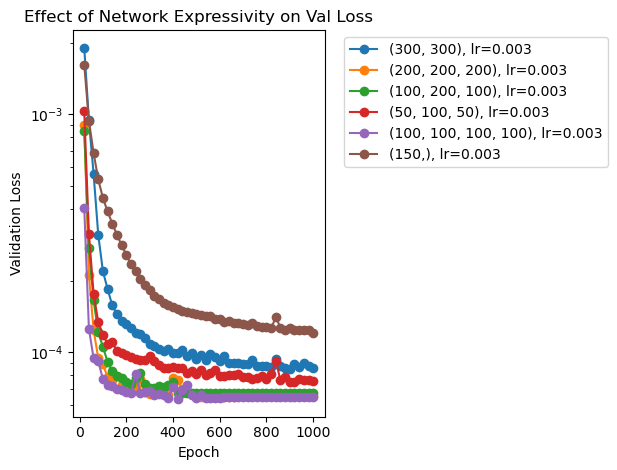

In [114]:
# Plot validation-loss curves
epochs = list(range(EVAL_INTERVAL, NUM_EPOCHS+1, EVAL_INTERVAL))
for (hidden_sizes, lr), losses in results.items():
    label = f"{hidden_sizes}, lr={lr}"
    plt.plot(epochs, losses, '-o', label=label)
plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.title("Effect of Network Expressivity on Val Loss")
plt.tight_layout()
plt.show()

In [115]:
# Print final losses
for (hidden_sizes, lr), losses in results.items():
    print(f"hidden={hidden_sizes}, lr={lr} → final val loss = {losses[-1]:.4e}")

hidden=(300, 300), lr=0.003 → final val loss = 8.5938e-05
hidden=(200, 200, 200), lr=0.003 → final val loss = 6.5215e-05
hidden=(100, 200, 100), lr=0.003 → final val loss = 6.7413e-05
hidden=(50, 100, 50), lr=0.003 → final val loss = 7.5918e-05
hidden=(100, 100, 100, 100), lr=0.003 → final val loss = 6.4586e-05
hidden=(150,), lr=0.003 → final val loss = 1.2025e-04


Architectures:   0%|          | 0/15 [00:00<?, ?it/s]

LRs (hs=[100]):   0%|          | 0/1 [00:00<?, ?it/s]

hs=[100], lr=0.003:   0%|          | 0/1000 [00:00<?, ?epoch/s]

LRs (hs=[100, 100]):   0%|          | 0/1 [00:00<?, ?it/s]

hs=[100, 100], lr=0.003:   0%|          | 0/1000 [00:00<?, ?epoch/s]

...

hs=[300, 300, 300], lr=0.003:   0%|          | 0/1000 [00:00<?, ?epoch/s]

LRs (hs=[300, 300, 300, 300, 300]):   0%|          | 0/1 [00:00<?, ?it/s]

hs=[300, 300, 300, 300, 300], lr=0.003:   0%|          | 0/1000 [00:00<?, ?epoch/s]

LRs (hs=[300, 300, 300, 300, 300, 300]):   0%|          | 0/1 [00:00<?, ?it/s]

hs=[300, 300, 300, 300, 300, 300], lr=0.003:   0%|          | 0/1000 [00:00<?, ?epoch/s]

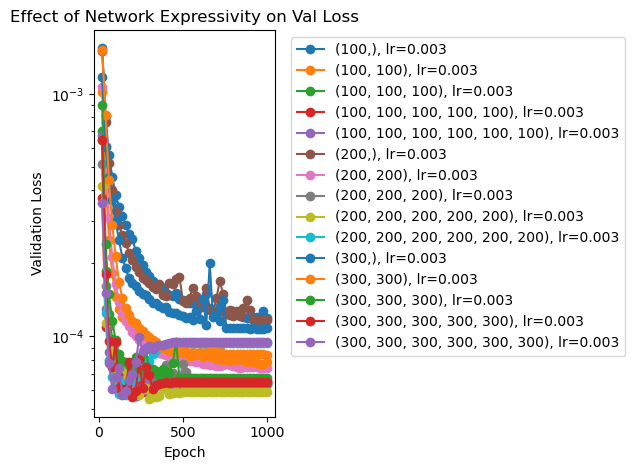

In [119]:
# Grid settings

methods = ['rk4']
hidden_sizes_list = [
    # Original 100-unit architectures
    [100],
    [100, 100],
    [100, 100, 100],
    [100, 100, 100, 100, 100],
    [100, 100, 100, 100, 100, 100],

    # Parallel 200-unit versions
    [200],
    [200, 200],
    [200, 200, 200],
    [200, 200, 200, 200, 200],
    [200, 200, 200, 200, 200, 200],

    # Parallel 300-unit versions
    [300],
    [300, 300],
    [300, 300, 300],
    [300, 300, 300, 300, 300],
    [300, 300, 300, 300, 300, 300],
]
lrs = [3e-3]

NUM_EPOCHS = 1000
EVAL_INTERVAL = 20  # record val loss every 20 epochs

save_dir = "expressivity_models"
os.makedirs(save_dir, exist_ok=True)

# Run the sweep over width/depth and learning rates
results = {}
for hidden_sizes in tqdm(hidden_sizes_list, desc="Architectures"):
    for lr in tqdm(lrs, desc=f"LRs (hs={hidden_sizes})", leave=False):
        losses = train_validate_plateau('rk4', lr, hidden_sizes)
        results[(tuple(hidden_sizes), lr)] = losses

# Plot validation-loss curves
epochs = list(range(EVAL_INTERVAL, NUM_EPOCHS+1, EVAL_INTERVAL))
for (hidden_sizes, lr), losses in results.items():
    label = f"{hidden_sizes}, lr={lr}"
    plt.plot(epochs, losses, '-o', label=label)
plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.title("Effect of Network Expressivity on Val Loss")
plt.tight_layout()
plt.show()

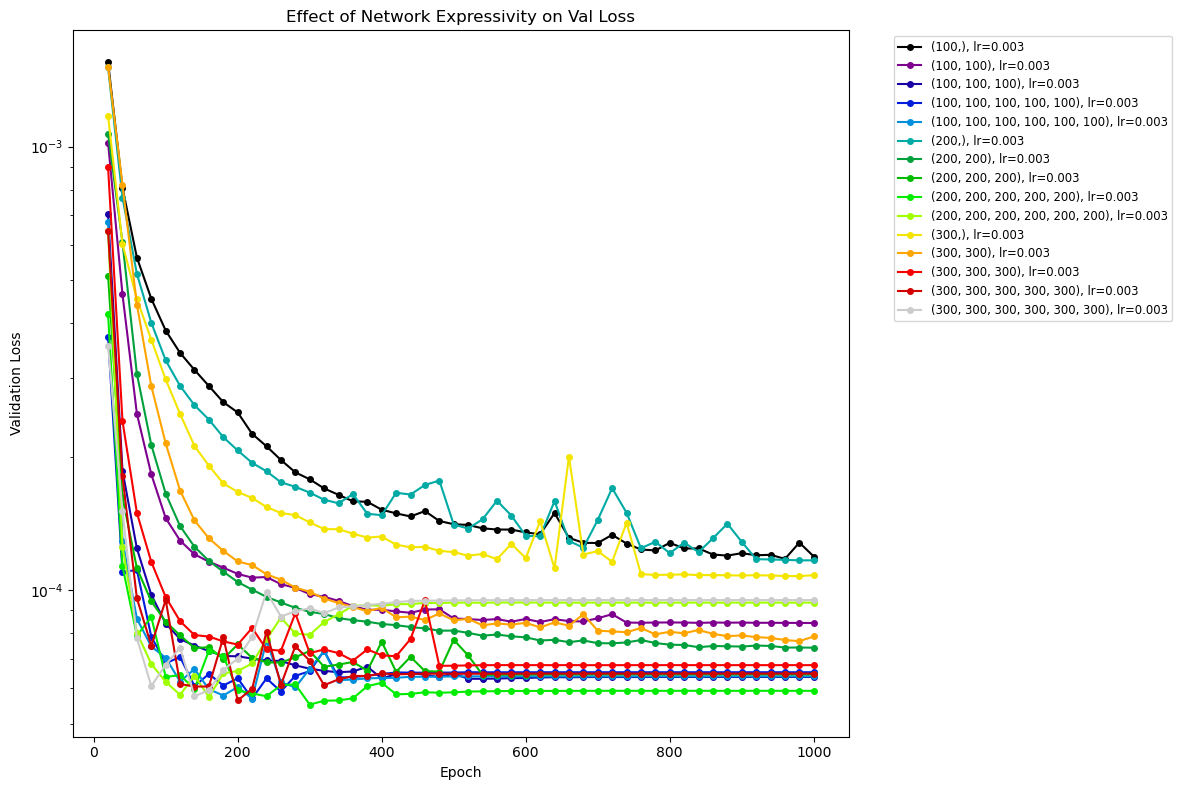

In [123]:
# Prepare epochs and a "rainbow" colormap
epochs = list(range(EVAL_INTERVAL, NUM_EPOCHS + 1, EVAL_INTERVAL))
cmap = plt.cm.nipy_spectral  # or plt.cm.rainbow, plt.cm.gist_ncar, etc.
n = len(results)
colors = cmap(np.linspace(0, 1, n))

plt.figure(figsize=(12, 8))
for idx, ((hidden_sizes, lr), losses) in enumerate(results.items()):
    plt.plot(
        epochs, losses,
        '-o',
        color=colors[idx],
        markersize=4,
        linewidth=1.5,
        label=f"{hidden_sizes}, lr={lr}"
    )

plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Effect of Network Expressivity on Val Loss")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

In [124]:
# Print final losses
for (hidden_sizes, lr), losses in results.items():
    print(f"hidden={hidden_sizes}, lr={lr} → final val loss = {losses[-1]:.4e}")

hidden=(100,), lr=0.003 → final val loss = 1.1899e-04
hidden=(100, 100), lr=0.003 → final val loss = 8.4248e-05
hidden=(100, 100, 100), lr=0.003 → final val loss = 6.3657e-05
hidden=(100, 100, 100, 100, 100), lr=0.003 → final val loss = 6.5254e-05
hidden=(100, 100, 100, 100, 100, 100), lr=0.003 → final val loss = 6.3883e-05
hidden=(200,), lr=0.003 → final val loss = 1.1665e-04
hidden=(200, 200), lr=0.003 → final val loss = 7.4118e-05
hidden=(200, 200, 200), lr=0.003 → final val loss = 6.4544e-05
hidden=(200, 200, 200, 200, 200), lr=0.003 → final val loss = 5.9252e-05
hidden=(200, 200, 200, 200, 200, 200), lr=0.003 → final val loss = 9.3678e-05
hidden=(300,), lr=0.003 → final val loss = 1.0805e-04
hidden=(300, 300), lr=0.003 → final val loss = 7.8561e-05
hidden=(300, 300, 300), lr=0.003 → final val loss = 6.7698e-05
hidden=(300, 300, 300, 300, 300), lr=0.003 → final val loss = 6.4791e-05
hidden=(300, 300, 300, 300, 300, 300), lr=0.003 → final val loss = 9.4916e-05


**Ordered by val losses:**

hidden=(200, 200, 200, 200, 200), lr=0.003 → 5.9252 × 10⁻⁵

hidden=(100, 100, 100), lr=0.003 → 6.3657 × 10⁻⁵

hidden=(100, 100, 100, 100, 100, 100), lr=0.003 → 6.3883 × 10⁻⁵

hidden=(200, 200, 200), lr=0.003 → 6.4544 × 10⁻⁵

hidden=(300, 300, 300, 300, 300), lr=0.003 → 6.4791 × 10⁻⁵

hidden=(100, 100, 100, 100, 100), lr=0.003 → 6.5254 × 10⁻⁵

hidden=(100, 200, 100), lr=0.003 → 6.7413 × 10⁻⁵

hidden=(300, 300, 300), lr=0.003 → 6.7698 × 10⁻⁵

hidden=(200, 200), lr=0.003 → 7.4118 × 10⁻⁵

hidden=(50, 100, 50), lr=0.003 → 7.5918 × 10⁻⁵

hidden=(300, 300), lr=0.003 → 7.8561 × 10⁻⁵

hidden=(100, 100), lr=0.003 → 8.4248 × 10⁻⁵

hidden=(200, 200, 200, 200, 200, 200), lr=0.003 → 9.3678 × 10⁻⁵

hidden=(300, 300, 300, 300, 300, 300), lr=0.003 → 9.4916 × 10⁻⁵

hidden=(300,), lr=0.003 → 1.0805 × 10⁻⁴

hidden=(200,), lr=0.003 → 1.1665 × 10⁻⁴

hidden=(100,), lr=0.003 → 1.1899 × 10⁻⁴

## 4 - Comparison Between NeuralODE and HW3

In [128]:
from learning_state_dynamics import ResidualDynamicsModel

**Hw3 models:**  
pushing_residual_dynamics_model.pt  
pushing_multi_step_residual_dynamics_model.pt

In [192]:
# Load the models
# -- single-step residual
residual_single = ResidualDynamicsModel(3,3)
residual_single.load_state_dict(torch.load(
    "pushing_residual_dynamics_model.pt", map_location="cpu"))
residual_single.eval()

# -- multi-step residual (num_steps=4)
residual_multi = ResidualDynamicsModel(3,3)
residual_multi.load_state_dict(torch.load(
    "pushing_multi_step_residual_dynamics_model.pt", map_location="cpu"))
residual_multi.eval()

# -- single-step NeuralODE
ode_single = NeuralODEModel(3,3,[100,100],'rk4')
ode_single.load_state_dict(torch.load(
    "single_rk4_models/model_rk4_lr0.005.pt", map_location="cpu"))
ode_single.eval()

# -- multi-step NeuralODE (num_steps=4)
ode_multi = NeuralODEModel(3,3,[100,100],'rk4')
ode_multi.load_state_dict(torch.load(
    "multiple_rk4_models/model_rk4_steps4_lr0.003.pt", map_location="cpu"))
ode_multi.eval()

C:\Users\hande\AppData\Local\Temp\ipykernel_34680\4070765057.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  residual_single.load_state_dict(torch.load(
C:\Users\hande\A

NeuralODEModel(
  (func): ODEFunc(
    (net): Sequential(
      (0): Linear(in_features=6, out_features=100, bias=True)
      (1): ReLU()
      (2): Linear(in_features=100, out_features=100, bias=True)
      (3): ReLU()
      (4): Linear(in_features=100, out_features=3, bias=True)
    )
  )
)

In [193]:
# single-step validation
val_ds1 = SingleStepDynamicsDataset(
    np.load('validation_data.npy', allow_pickle=True))
val_loader1 = torch.utils.data.DataLoader(val_ds1, batch_size=len(val_ds1))

# 4-step validation
num_steps = 4
val_ds4 = MultiStepDynamicsDataset(
    np.load('validation_data.npy', allow_pickle=True),
    num_steps=num_steps)
val_loader4 = torch.utils.data.DataLoader(val_ds4, batch_size=len(val_ds4))

pose_fn   = SE2PoseLoss(block_width=0.1, block_length=0.1)
ss_loss   = SingleStepLoss(pose_fn)
ms_loss   = MultiStepLoss(pose_fn, discount=1.0)

In [194]:
# Compute losses
# single-step
loss_res1 = 0.0
loss_ode1 = 0.0
for batch in val_loader1:
    s,u,sn = batch['state'], batch['action'], batch['next_state']
    loss_res1 += ss_loss(residual_single, s, u, sn).item()
    loss_ode1 += ss_loss(ode_single,      s, u, sn).item()

# multi-step (normalize by num_steps)
loss_res4 = 0.0
loss_ode4 = 0.0
for batch in val_loader4:
    s, ua, xs = batch['state'], batch['action'], batch['next_state']
    loss_res4 += ms_loss(residual_multi, s, ua, xs).item()
    loss_ode4 += ms_loss(ode_multi,      s, ua, xs).item()
loss_res4 /= num_steps
loss_ode4 /= num_steps

print(f"Single-step residual loss = {loss_res1:.4e}")
print(f"Single-step NeuralODE loss = {loss_ode1:.4e}")
print(f"4-step residual loss       = {loss_res4:.4e}")
print(f"4-step NeuralODE loss      = {loss_ode4:.4e}")

Single-step residual loss = 8.1748e-05
Single-step NeuralODE loss = 7.2605e-05
4-step residual loss       = 2.3952e-04
4-step NeuralODE loss      = 2.4969e-04


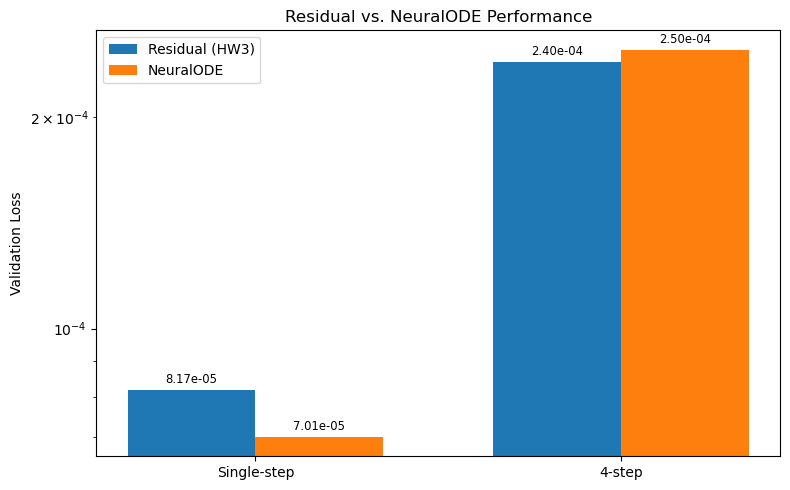

In [145]:
# Plot grouped bar chart
labels      = ['Single-step', '4-step']
res_losses  = [loss_res1, loss_res4]
ode_losses  = [loss_ode1, loss_ode4]

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
bars1 = ax.bar(x - width/2, res_losses, width, label='Residual (HW3)')
bars2 = ax.bar(x + width/2, ode_losses, width, label='NeuralODE')

# Log scale
ax.set_yscale('log')
ax.set_ylabel('Validation Loss')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('Residual vs. NeuralODE Performance')
ax.legend()

# Annotate bar heights
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(
        f"{height:.2e}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),  # 3 points vertical offset
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize='small'
    )

plt.tight_layout()
plt.show()

## 5 - Use the Learned Dynamics Model for Planning and Controls (originally part 4 from HW 3)

**Please note - the file `mppi.py` will be released on the course website on 02/24/2025. You will not be able to complete this section until then.**


Finally, once we have a good model of the pushing dynamics, we can use it to plan a sequence of actions to reach the goal configuration.

To do so, we will be using MPPI as our controller. It will rollout the trajectories using the learned dynamics model from the previous section. Since in HW2 you already implemented MPPI, here we are giving you the implmentation. You will just have to implement the cost function and some other minor parts. We are also giving you some good initialization for the hyperparametes. However, you may need to tune them for your model and cost function implementations.

You should use the `pushing_multistep_residual_dynamics_model` you trained previously as the dynamics model to complete this question.  


In [197]:
from learning_state_dynamics import PushingController, free_pushing_cost_function, collision_detection, obstacle_avoidance_pushing_cost_function
from panda_pushing_env import TARGET_POSE_FREE, TARGET_POSE_OBSTACLES, BOX_SIZE

Load the models

In [198]:
# Load the models
# -- single-step residual
residual_single = ResidualDynamicsModel(3,3)
residual_single.load_state_dict(torch.load(
    "pushing_residual_dynamics_model.pt", map_location="cpu"))
residual_single.eval()

# -- multi-step residual (num_steps=4)
residual_multi = ResidualDynamicsModel(3,3)
residual_multi.load_state_dict(torch.load(
    "pushing_multi_step_residual_dynamics_model.pt", map_location="cpu"))
residual_multi.eval()

# -- single-step NeuralODE
ode_single = NeuralODEModel(3,3,[100,100],'rk4')
ode_single.load_state_dict(torch.load(
    "single_rk4_models/model_rk4_lr0.005.pt", map_location="cpu"))
ode_single.eval()

# -- multi-step NeuralODE (num_steps=4)
ode_multi = NeuralODEModel(3,3,[100,100],'rk4')
ode_multi.load_state_dict(torch.load(
    "multiple_rk4_models/model_rk4_steps4_lr0.003.pt", map_location="cpu"))
ode_multi.eval()

C:\Users\hande\AppData\Local\Temp\ipykernel_34680\4070765057.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  residual_single.load_state_dict(torch.load(
C:\Users\hande\A

NeuralODEModel(
  (func): ODEFunc(
    (net): Sequential(
      (0): Linear(in_features=6, out_features=100, bias=True)
      (1): ReLU()
      (2): Linear(in_features=100, out_features=100, bias=True)
      (3): ReLU()
      (4): Linear(in_features=100, out_features=3, bias=True)
    )
  )
)

### 4.1 - Obstacle-Free Pushing
In this first part, we will consider the task of pushing an object to a goal pose with no obstacles on the table. We will use the following quadratic cost:

$$\text{Cost}(\mathbf x_1, ..., \mathbf x_T) = \sum^T_{t=1} (\mathbf x_t - \mathbf x_{goal})^T Q (\mathbf x_t - \mathbf x_{goal})$$

with 
$$ Q = \begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 0.1
\end{bmatrix}$$
**TODO:**
* Implement `free_pushing_cost_function` in `learning_state_dynamics.py`.
  This function should compute the state cost for MPPI as defined above.  
* Complete the MPPI-based controller class `PushingController` in `learning_state_dynamics.py`.
  You need to implement:
   * Tune MPPI controller hyperparameters in the `__init__` method.
   * Implement the `_compute_dynamics` method which should compute `next_state` from `state` and `action`.
   * Implement the `control` method which should return the `action` from a `state`. 
   
Read all docstrings carefully for details about the expected inputs, outputs and uses.

You should expect to see the robot pushing the block directly to the goal, typically finishing this task in fewer than 10 steps. 


#### 4.1.1 Residual Single Step (residual_single)

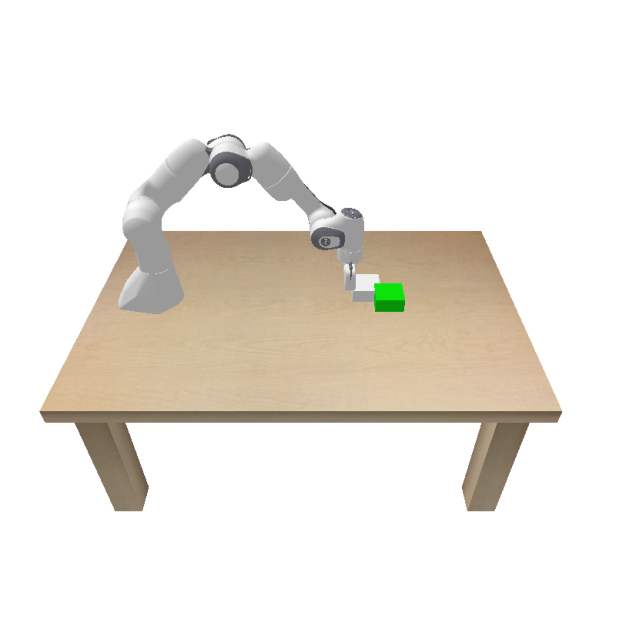

  0%|          | 0/20 [00:00<?, ?it/s]

GOAL REACHED: True


In [244]:
# Control on an obstacle free environment
%matplotlib inline

fig = plt.figure(figsize=(8,8))
hfig = display(fig, display_id=True)
visualizer = NotebookVisualizer(fig=fig, hfig=hfig)


env = PandaPushingEnv(visualizer=visualizer, render_non_push_motions=False,  camera_heigh=800, camera_width=800, render_every_n_steps=5)
#controller = PushingController(env, single_model, free_pushing_cost_function, num_samples=100, horizon=10)

controller = PushingController(env, residual_single, free_pushing_cost_function, 100, 10)

# Move MPPI’s internal buffers to the same device as your NeuralODE
mp = controller.mppi
device = next(controller.model.parameters()).device

# # force both U and noise to GPU
# mp.U     = mp.U.to(device)
# mp.noise = mp.noise.to(device)


for name in ['U', 'noise', 'noise_sigma_inv', 'u_init', 'states', 'actions', 'cost_total']:
    if hasattr(mp, name):
        tensor = getattr(mp, name)
        if isinstance(tensor, torch.Tensor):
            setattr(mp, name, tensor.to(device))
            
# # force MPPI to use the model’s device:
# controller.mppi.d = next(single_model.parameters()).device
# controller.mppi.dtype = single_model.parameters().__next__().dtype


# env.reset()

# state_0 = env.reset()
# state = state_0

state = env.reset()

# num_steps_max = 100
num_steps_max = 20

for i in tqdm(range(num_steps_max)):
    action = controller.control(state)
    state, reward, done, _ = env.step(action)
    if done:
        break

        
# Evaluate if goal is reached
end_state = env.get_state()
target_state = TARGET_POSE_FREE
goal_distance = np.linalg.norm(end_state[:2]-target_state[:2]) # evaluate only position, not orientation
goal_reached = goal_distance < BOX_SIZE

print(f'GOAL REACHED: {goal_reached}')
        
        
plt.close(fig)



#### 4.1.2 NeuralODE Single Step (ode_single)

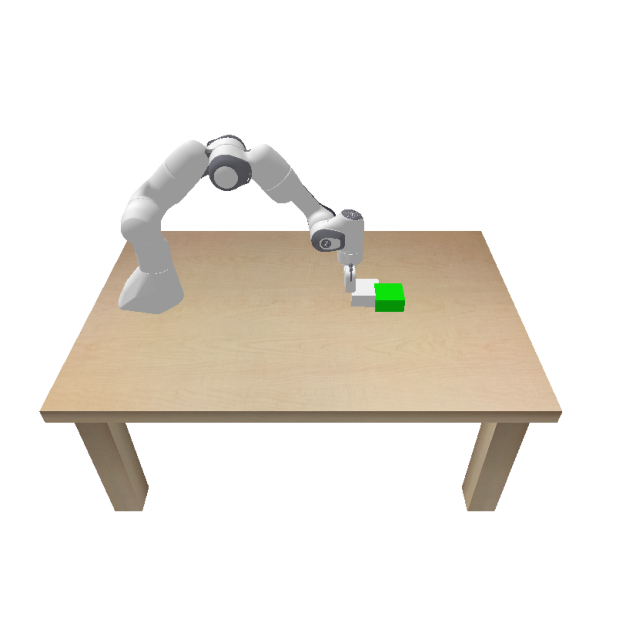

  0%|          | 0/20 [00:00<?, ?it/s]

GOAL REACHED: True


In [245]:
# Control on an obstacle free environment
%matplotlib inline

fig = plt.figure(figsize=(8,8))
hfig = display(fig, display_id=True)
visualizer = NotebookVisualizer(fig=fig, hfig=hfig)


env = PandaPushingEnv(visualizer=visualizer, render_non_push_motions=False,  camera_heigh=800, camera_width=800, render_every_n_steps=5)
#controller = PushingController(env, single_model, free_pushing_cost_function, num_samples=100, horizon=10)

controller = PushingController(env, ode_single, free_pushing_cost_function, 100, 10)

# Move MPPI’s internal buffers to the same device as your NeuralODE
mp = controller.mppi
device = next(controller.model.parameters()).device


for name in ['U', 'noise', 'noise_sigma_inv', 'u_init', 'states', 'actions', 'cost_total']:
    if hasattr(mp, name):
        tensor = getattr(mp, name)
        if isinstance(tensor, torch.Tensor):
            setattr(mp, name, tensor.to(device))

# env.reset()

# state_0 = env.reset()
# state = state_0

state = env.reset()

# num_steps_max = 100
num_steps_max = 20

for i in tqdm(range(num_steps_max)):
    action = controller.control(state)
    state, reward, done, _ = env.step(action)
    if done:
        break

        
# Evaluate if goal is reached
end_state = env.get_state()
target_state = TARGET_POSE_FREE
goal_distance = np.linalg.norm(end_state[:2]-target_state[:2]) # evaluate only position, not orientation
goal_reached = goal_distance < BOX_SIZE

print(f'GOAL REACHED: {goal_reached}')
        
        
plt.close(fig)



#### 4.1.3 Residual Multi Step

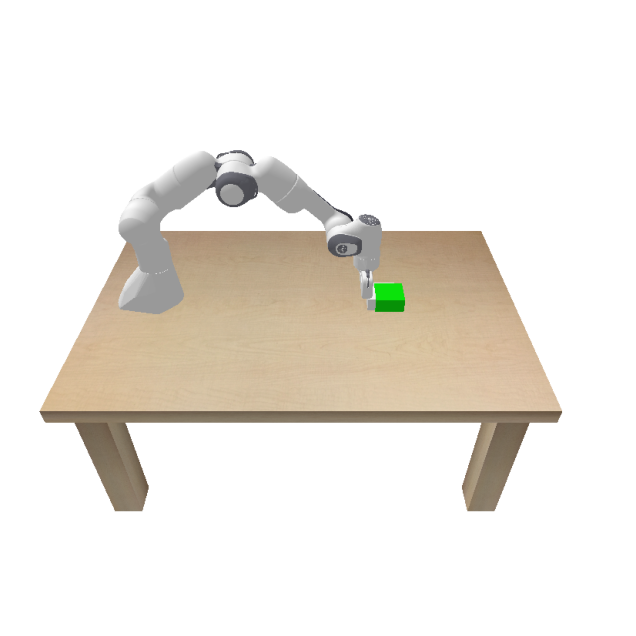

  0%|          | 0/20 [00:00<?, ?it/s]

GOAL REACHED: True


In [246]:
# Control on an obstacle free environment
%matplotlib inline

fig = plt.figure(figsize=(8,8))
hfig = display(fig, display_id=True)
visualizer = NotebookVisualizer(fig=fig, hfig=hfig)


env = PandaPushingEnv(visualizer=visualizer, render_non_push_motions=False,  camera_heigh=800, camera_width=800, render_every_n_steps=5)
#controller = PushingController(env, single_model, free_pushing_cost_function, num_samples=100, horizon=10)

controller = PushingController(env, residual_multi, free_pushing_cost_function, 100, 10)

# Move MPPI’s internal buffers to the same device as your NeuralODE
mp = controller.mppi
device = next(controller.model.parameters()).device


for name in ['U', 'noise', 'noise_sigma_inv', 'u_init', 'states', 'actions', 'cost_total']:
    if hasattr(mp, name):
        tensor = getattr(mp, name)
        if isinstance(tensor, torch.Tensor):
            setattr(mp, name, tensor.to(device))

# env.reset()

# state_0 = env.reset()
# state = state_0

state = env.reset()

# num_steps_max = 100
num_steps_max = 20

for i in tqdm(range(num_steps_max)):
    action = controller.control(state)
    state, reward, done, _ = env.step(action)
    if done:
        break

        
# Evaluate if goal is reached
end_state = env.get_state()
target_state = TARGET_POSE_FREE
goal_distance = np.linalg.norm(end_state[:2]-target_state[:2]) # evaluate only position, not orientation
goal_reached = goal_distance < BOX_SIZE

print(f'GOAL REACHED: {goal_reached}')
        
        
plt.close(fig)



#### 4.1.4 NeuralODE Multi Step

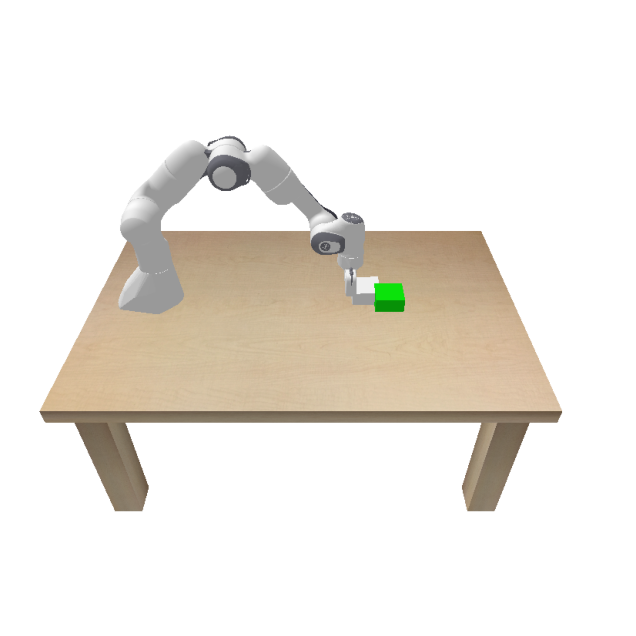

  0%|          | 0/20 [00:00<?, ?it/s]

GOAL REACHED: True


In [247]:
# Control on an obstacle free environment
%matplotlib inline

fig = plt.figure(figsize=(8,8))
hfig = display(fig, display_id=True)
visualizer = NotebookVisualizer(fig=fig, hfig=hfig)


env = PandaPushingEnv(visualizer=visualizer, render_non_push_motions=False,  camera_heigh=800, camera_width=800, render_every_n_steps=5)
#controller = PushingController(env, single_model, free_pushing_cost_function, num_samples=100, horizon=10)

controller = PushingController(env, ode_multi, free_pushing_cost_function, 100, 10)

# Move MPPI’s internal buffers to the same device as your NeuralODE
mp = controller.mppi
device = next(controller.model.parameters()).device


for name in ['U', 'noise', 'noise_sigma_inv', 'u_init', 'states', 'actions', 'cost_total']:
    if hasattr(mp, name):
        tensor = getattr(mp, name)
        if isinstance(tensor, torch.Tensor):
            setattr(mp, name, tensor.to(device))

# env.reset()

# state_0 = env.reset()
# state = state_0

state = env.reset()

# num_steps_max = 100
num_steps_max = 20

for i in tqdm(range(num_steps_max)):
    action = controller.control(state)
    state, reward, done, _ = env.step(action)
    if done:
        break

        
# Evaluate if goal is reached
end_state = env.get_state()
target_state = TARGET_POSE_FREE
goal_distance = np.linalg.norm(end_state[:2]-target_state[:2]) # evaluate only position, not orientation
goal_reached = goal_distance < BOX_SIZE

print(f'GOAL REACHED: {goal_reached}')
        
        
plt.close(fig)



In [248]:
# # To fix autoload fail issue.

# # Read your file (ignoring any invalid bytes), then re-write it as UTF-8
# import io

# src = "learning_state_dynamics.py"
# # 1) Read with utf-8 but ignore bad sequences
# with io.open(src, "r", encoding="utf-8", errors="ignore") as f:
#     text = f.read()

# # 2) Optional: Add a UTF-8 coding header at the very top
# if not text.startswith("# -*- coding: utf-8 -*-"):
#     text = "# -*- coding: utf-8 -*-\n" + text

# # 3) Write back in UTF-8
# with io.open(src, "w", encoding="utf-8") as f:
#     f.write(text)

# print(f"Re-saved {src} as UTF-8.")

### 4.2 - Pushing with Obstacles
Now, we will repeat the task but adding an obstacle to the scene. The goal is to push the block to the goal while avoiding the obstacle.
You will have to first implement a basic collision detection algorithm. 

Then, you will have to use the collision detection inside the cost function to assign high cost to in-collision trajectories

#### 4.2.1 - Collision Detection Function

The obstacle we are considering is a rectangle. At a given SE2 pose $[x, y, \theta]$ we can check collision by checking whether or not these two rectangles intersect. 

![Action Space](https://drive.google.com/uc?export=view&id=1yC2SxtbtmhInkYk-rzR2TAAYuD4JM-I0)

**TODO:**
* Implement `collision_detection` in `learning_state_dynamics.py`.
* The relevant parameters $(w, w_{obs} l_{obs}, x_{obs}, y_{obs})$ are already specified inside the function as `box_size`, `obstacle_dims`, and `obstacle_centre`. 


In [249]:
from learning_state_dynamics import collision_detection

# let's test the collision detection with two states
# The first should be in collision, the second should not

states = torch.tensor([
    [0.6, 0.2, 0.0],
    [0.3, 0.15, 0.7]
])

collision = collision_detection(states)

print(f'First state in collision? {collision[0]}')
print(f'Second state in collision? {collision[1]}')


First state in collision? 1.0
Second state in collision? 0.0


#### 4.2.2 - Cost Function for Obstacle Avoidance

You should implement a new cost function to reach the goal while avoiding the obstacle. The cost should be
$$\text{Cost}(\mathbf x_1, ..., \mathbf x_T) = \sum^T_{t=1} \left((\mathbf x_t - \mathbf x_{goal})^T Q (\mathbf x_t - \mathbf x_{goal}) + 100 \texttt{in\_collision}(\mathbf x_t)\right)$$

With $Q$ defined as in the obstacle-free case, and `in_collision` is the binary output of the collision detection function you implemented above. This should add an additional state cost of 100 whenever a state is in collision.

**TODO:**

* Implement `obstacle_avoidance_pushing_cost_function` in `learning_state_dynamics.py`.

If implemented successfully, you should see the robot pushing the block around the obstacle to the goal. The robot should complete the task within the 20 steps, but may take 15-20 steps to do so. Even with a good dynamics model the robot may occasionally get the block stuck on the obstacle, but should complete the task successfully more often than not.

#### 4.2.3 - residual_single

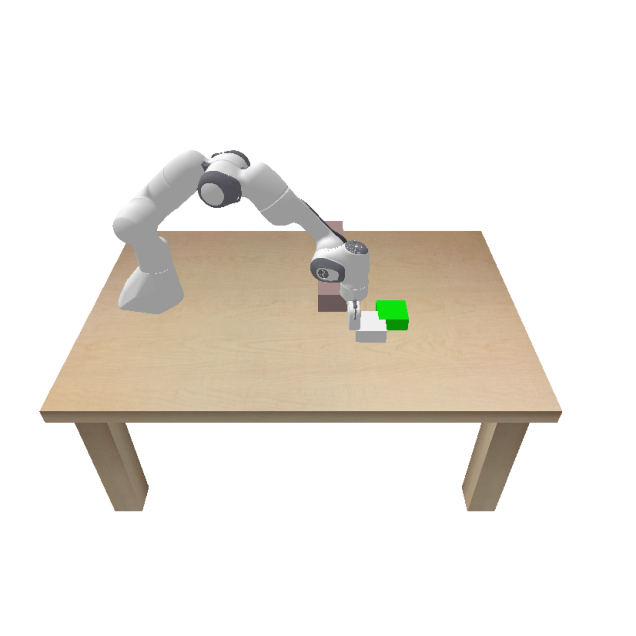

  0%|          | 0/20 [00:00<?, ?it/s]

GOAL REACHED: True


In [250]:
# Control on an obstacle free environment
%matplotlib inline

fig = plt.figure(figsize=(8,8))
hfig = display(fig, display_id=True)
visualizer = NotebookVisualizer(fig=fig, hfig=hfig)

# set up controller and environment
env = PandaPushingEnv(visualizer=visualizer, render_non_push_motions=False,  include_obstacle=True, camera_heigh=800, camera_width=800, render_every_n_steps=5)
controller = PushingController(env, residual_single,
                               obstacle_avoidance_pushing_cost_function, num_samples=1000, horizon=20)
env.reset()

state_0 = env.reset()
state = state_0

num_steps_max = 20

for i in tqdm(range(num_steps_max)):
    action = controller.control(state)
    state, reward, done, _ = env.step(action)
    if done:
        break

        
# Evaluate if goal is reached
end_state = env.get_state()
target_state = TARGET_POSE_OBSTACLES
goal_distance = np.linalg.norm(end_state[:2]-target_state[:2]) # evaluate only position, not orientation
goal_reached = goal_distance < BOX_SIZE

print(f'GOAL REACHED: {goal_reached}')
        
        
# Evaluate state
plt.close(fig)

#### 4.2.4 - ode_single

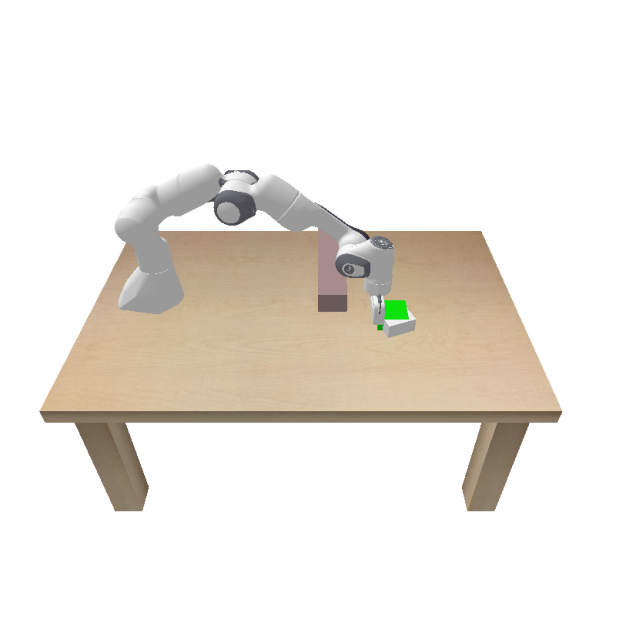

  0%|          | 0/20 [00:00<?, ?it/s]

GOAL REACHED: True


In [251]:
# Control on an obstacle free environment
%matplotlib inline

fig = plt.figure(figsize=(8,8))
hfig = display(fig, display_id=True)
visualizer = NotebookVisualizer(fig=fig, hfig=hfig)

# set up controller and environment
env = PandaPushingEnv(visualizer=visualizer, render_non_push_motions=False,  include_obstacle=True, camera_heigh=800, camera_width=800, render_every_n_steps=5)
controller = PushingController(env, ode_single,
                               obstacle_avoidance_pushing_cost_function, num_samples=1000, horizon=20)
env.reset()

state_0 = env.reset()
state = state_0

num_steps_max = 20

for i in tqdm(range(num_steps_max)):
    action = controller.control(state)
    state, reward, done, _ = env.step(action)
    if done:
        break

        
# Evaluate if goal is reached
end_state = env.get_state()
target_state = TARGET_POSE_OBSTACLES
goal_distance = np.linalg.norm(end_state[:2]-target_state[:2]) # evaluate only position, not orientation
goal_reached = goal_distance < BOX_SIZE

print(f'GOAL REACHED: {goal_reached}')
        
        
# Evaluate state
plt.close(fig)

#### 4.2.5 - residual_multi

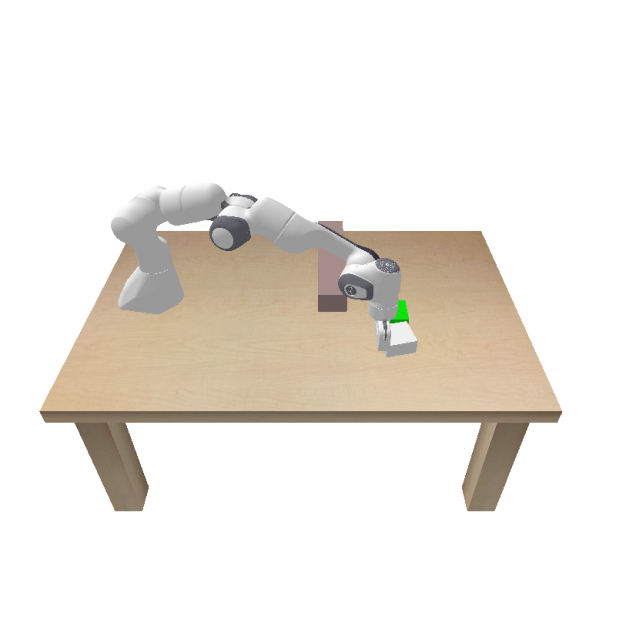

  0%|          | 0/20 [00:00<?, ?it/s]

GOAL REACHED: False


In [252]:
# Control on an obstacle free environment
%matplotlib inline

fig = plt.figure(figsize=(8,8))
hfig = display(fig, display_id=True)
visualizer = NotebookVisualizer(fig=fig, hfig=hfig)

# set up controller and environment
env = PandaPushingEnv(visualizer=visualizer, render_non_push_motions=False,  include_obstacle=True, camera_heigh=800, camera_width=800, render_every_n_steps=5)
controller = PushingController(env, residual_multi,
                               obstacle_avoidance_pushing_cost_function, num_samples=1000, horizon=20)
env.reset()

state_0 = env.reset()
state = state_0

num_steps_max = 20

for i in tqdm(range(num_steps_max)):
    action = controller.control(state)
    state, reward, done, _ = env.step(action)
    if done:
        break

        
# Evaluate if goal is reached
end_state = env.get_state()
target_state = TARGET_POSE_OBSTACLES
goal_distance = np.linalg.norm(end_state[:2]-target_state[:2]) # evaluate only position, not orientation
goal_reached = goal_distance < BOX_SIZE

print(f'GOAL REACHED: {goal_reached}')
        
        
# Evaluate state
plt.close(fig)

#### 4.2.6 - ode_multi

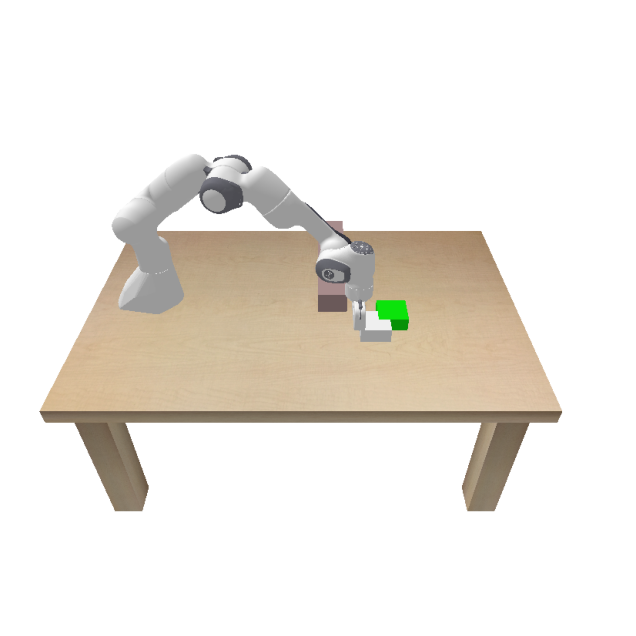

  0%|          | 0/20 [00:00<?, ?it/s]

GOAL REACHED: True


In [253]:
# Control on an obstacle free environment
%matplotlib inline

fig = plt.figure(figsize=(8,8))
hfig = display(fig, display_id=True)
visualizer = NotebookVisualizer(fig=fig, hfig=hfig)

# set up controller and environment
env = PandaPushingEnv(visualizer=visualizer, render_non_push_motions=False,  include_obstacle=True, camera_heigh=800, camera_width=800, render_every_n_steps=5)
controller = PushingController(env, ode_multi,
                               obstacle_avoidance_pushing_cost_function, num_samples=1000, horizon=20)
env.reset()

state_0 = env.reset()
state = state_0

num_steps_max = 20

for i in tqdm(range(num_steps_max)):
    action = controller.control(state)
    state, reward, done, _ = env.step(action)
    if done:
        break

        
# Evaluate if goal is reached
end_state = env.get_state()
target_state = TARGET_POSE_OBSTACLES
goal_distance = np.linalg.norm(end_state[:2]-target_state[:2]) # evaluate only position, not orientation
goal_reached = goal_distance < BOX_SIZE

print(f'GOAL REACHED: {goal_reached}')
        
        
# Evaluate state
plt.close(fig)